In [13]:
import json
import numpy as np
import os
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from factor_analyzer import Rotator

from sklearn.manifold import MDS
from scipy.spatial.distance import pdist, squareform

from scipy.cluster.hierarchy import linkage, dendrogram

In [14]:
def process_single_output(output_text): 
    if isinstance(output_text, dict): 
        output_text = output_text["content"]
    if "{" in output_text: 
        response = output_text.split("{")[1]
        response = response.split("}")[0]
        response = "{" + response + "}"
        response_json = ""
        try: 
            response_json = json.loads(response)
        except Exception as e: 
            # print(f"Could not load JSON accurately for model output = {response}")
            return None
        
        if not response_json:
            return None
        
        if "Question 1" not in response_json or "Question 2" not in response_json: 
            # print(f"Invalid keys found in response JSON = {response_json}")
            return None
        
        q1 = response_json["Question 1"]
        q2 = response_json["Question 2"]
        return q1, q2

    return None

In [16]:
def get_appraisal_data(file):
    appraisal_dict = {
        "pleasantness": [],
        "enjoyment": [],
        "consider": [],
        "attention": [],
        "understand": [],
        "control-situational": [],
        "control-self": [],
        "control-other": [],
        "certainty": [],
        "problem": [],
        "obstacle": [],
        "legitimacy-cheated": [],
        "legitimacy-fair": [],
        "responsibility-self": [],
        "responsibility-other": [],
        "exert": [],
        "effort": []
    }
    emotion_labels = []

    with open(file, "r") as f: 
        for i, line in enumerate(f.readlines()): 
            curr_json = json.loads(line)
            curr_emotion = curr_json["id"].split("_")[1]
            processed_output = process_single_output(curr_json["output"])
            
            rating = None
            if processed_output: 
                a1, a2 = processed_output
                if isinstance(a2, list):
                    if len(a2) == 2: 
                        rating = a2[1]

                if isinstance(a2, int):
                    rating = a2
            
            curr_dim = curr_json["id"].split("_")[-1]
            appraisal_dict[curr_dim].append(rating)

            if i % 17 == 0: 
                emotion_labels.append(curr_emotion)
        
        # for key, value in appraisal_dict.items(): 
        #     print(f"{key}: {len(appraisal_dict[key])}")

    return appraisal_dict, emotion_labels


def process_df(appraisal_dict, emotion_labels): 
    df = pd.DataFrame(appraisal_dict)
    print(f"Null values: ")
    print(df.isnull().sum())
    print(f"Filling with Zeroes:")
    df_filled = df.fillna(0)
    print(df_filled.head(5))
    df_clean = df_filled.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)
    df_clean["emotion"] = emotion_labels

    return df_clean

In [15]:
def pca(df_filled, name):
    include_columns = [c for c in df_filled.columns if c != "emotion"]
    df_filled = df_filled[include_columns]
    result_path = "./results_new"
    sns.color_palette("rocket", as_cmap=True)
    scaler = StandardScaler()
    X = df_filled.values
    X_scaled = scaler.fit_transform(X)  # Shape: (300, 18)

    pca = PCA(n_components=6)
    X_pca = pca.fit_transform(X_scaled)
    explained = pca.explained_variance_ratio_

    print(f"Explained Variance Ratio = {explained}")
    print(f"Total explained Variance = {np.sum(explained)}")

    plt.plot(np.cumsum(explained), marker='o')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('Scree Plot')
    plt.grid()
    plt.show()

    loadings = pd.DataFrame(pca.components_.T, 
                        columns=[f'PC{i+1}' for i in range(len(explained))],
                        index=list(df_filled.columns))
    
    n_components = 6
    rotator = Rotator(method='varimax')
    rotated_loadings = rotator.fit_transform(pca.components_[:n_components].T)

    rotated_df = pd.DataFrame(rotated_loadings,
                            index=list(df_filled.columns),
                            columns=[f'Factor{i+1}' for i in range(n_components)])
    print(rotated_df)

    plt.figure(figsize=(12, 8))
    sns.heatmap(rotated_df, annot=True, center=0, cmap="coolwarm")
    plt.title(f'Rotated PCA Loadings for {name}', fontsize=18)
    plt.yticks(fontsize=18)
    file_path = os.path.join(result_path, name.lower().replace(" ", "_") + "_pca_varimax.pdf")
    plt.savefig(file_path, format = "pdf", bbox_inches="tight")
    plt.show()
    
    return rotated_df


def top_features_per_factor(df, top_n=3):
    top_features = {}

    for col in df.columns:
        # Get top n features by absolute value
        top = df[col].abs().nlargest(top_n)
        top_indices = top.index
        top_features[col] = [(idx, df.loc[idx, col]) for idx in top_indices]

    return pd.DataFrame(top_features)

In [31]:
def plot_pca_rankings(models_data):

    # Infer number of components (assumed same for all models)
    first_key = next(iter(models_data.keys()))
    n_components = len(models_data[first_key][0])
    assert all(len(vals[0]) == n_components for vals in models_data.values()), "All models must have the same number of components."
    assert all(len(vals[1]) == n_components for vals in models_data.values()), "Each model must have the same number of factor labels as components."

    # X positions and labels
    model_names = list(models_data.keys())
    x = np.arange(len(model_names))

    # Choose a consistent color for each PC across models
    # We'll use a colormap to generate n_components distinct colors
    # cmap = plt.cm.get_cmap("Set2", n_components)  # 10 is fine for up to 10 comps; here we have 6
    # colors = [cmap(i) for i in range(n_components)]
    colors = ["#A0C4FF", "#9BF6FF", "#CAFFBF", "#FDFFB6", "#FFD6A5", "#FFADAD", "#f0f3bd"]
    # colors = sns.color_palette("husl", n_components)
    fig, ax = plt.subplots(figsize=(14, 12))

    # Plot stacks: ensure PC1 is on the bottom, then PC2, ..., up to PC6 on top
    bottom = np.zeros(len(model_names))

    # Gather variances into an array for easier handling
    variance_matrix = np.array([models_data[m][0] for m in model_names])  # shape: (n_models, n_components)
    factor_matrix = np.array([models_data[m][1] for m in model_names], dtype=object)

    bars = []
    for pc_idx in range(n_components):
        heights = variance_matrix[:, pc_idx]
        bar = ax.bar(x, heights, bottom=bottom, label=f"PC{pc_idx+1}", width=0.9, color=colors[pc_idx])
        bars.append(bar)
        
        # Annotate each segment with the model-specific factor acronym (e.g., "PL", "RES")
        for i, rect in enumerate(bar):
            h = rect.get_height()
            if h <= 0:
                continue
            # Place text in the vertical middle of the segment
            y_text = rect.get_y() + h / 2.0
            label = str(factor_matrix[i, pc_idx])
            # If the segment is tall enough, write inside; else write just above with a small offset
            if h >= 0.03:  # threshold; tweak if needed
                ax.text(rect.get_x() + rect.get_width() / 2.0, y_text, label,
                        ha='center', va='center', fontsize=15)
            else:
                ax.text(rect.get_x() + rect.get_width() / 2.0, rect.get_y() + h + 0.005, label,
                        ha='center', va='bottom', fontsize=15)
        bottom += heights

    # Format axes
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, fontsize=20)
    ax.set_ylabel("Explained Variance (proportion)", fontsize=22)
    ax.set_yticklabels(np.linspace(0.0, 1.0, 5).tolist(), fontsize=20)
    # ax.set_title("Latent Dimensions of Appraisal", fontsize=20)
    ax.set_ylim(0, max(1.0, (variance_matrix.sum(axis=1).max() + 0.05)))

    # Add legend for PCs (consistent colors across models)
    legend = ax.legend(title="Components", title_fontsize=18, loc="upper right", ncol=1, frameon=True, fontsize=18)

    plt.tight_layout()
    out_path = "./results_new/human_vs_model_pca.pdf"
    plt.savefig(out_path, dpi=200, format="pdf", bbox_inches="tight")

### With Emotions: Vanilla

Null values: 
pleasantness            0
enjoyment               0
consider                0
attention               0
understand              0
control-situational     0
control-self            0
control-other           0
certainty               0
problem                 0
obstacle                1
legitimacy-cheated      0
legitimacy-fair         0
responsibility-self     0
responsibility-other    1
exert                   0
effort                  0
dtype: int64
Filling with Zeroes:
   pleasantness  enjoyment  consider attention  understand  \
0             5         10         1         5          11   
1             5         11         1         5           8   
2             5         11         2         5          11   
3             5         11         2         4          11   
4             5         11         2         5          11   

   control-situational control-self  control-other  certainty problem  \
0                    2           10              1         11   

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_8068/3561297153.py:58: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_filled.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)


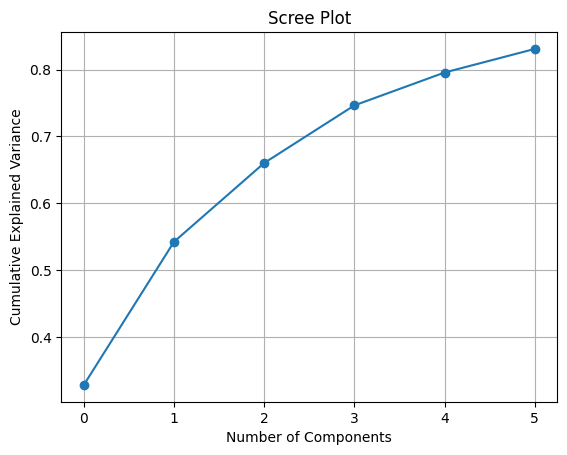

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness          0.326818  0.153642 -0.283733 -0.044205  0.186091   
enjoyment             0.297895  0.145022 -0.311235 -0.041337  0.198818   
consider              0.054623  0.047943  0.591952 -0.063009  0.017605   
attention            -0.117197 -0.025183 -0.600635 -0.043625 -0.049183   
understand            0.032721 -0.081341 -0.119764  0.682642 -0.044819   
control-situational  -0.120220 -0.095070  0.012361  0.030402  0.921561   
control-self         -0.010903  0.480435 -0.114904  0.048541 -0.119430   
control-other        -0.078888 -0.357655 -0.027125 -0.053468 -0.097812   
certainty             0.007614  0.167254  0.158999  0.678936  0.082661   
problem              -0.459642 -0.070429 -0.037030 -0.022855  0.002249   
obstacle             -0.412610  0.017639  0.021498  0.021054  0.085379   
legitimacy-cheated   -0.120141 -0.239473 -0.154306  0.213264 -0.156180   
legitimacy-fair      -0.044334 -0.0046

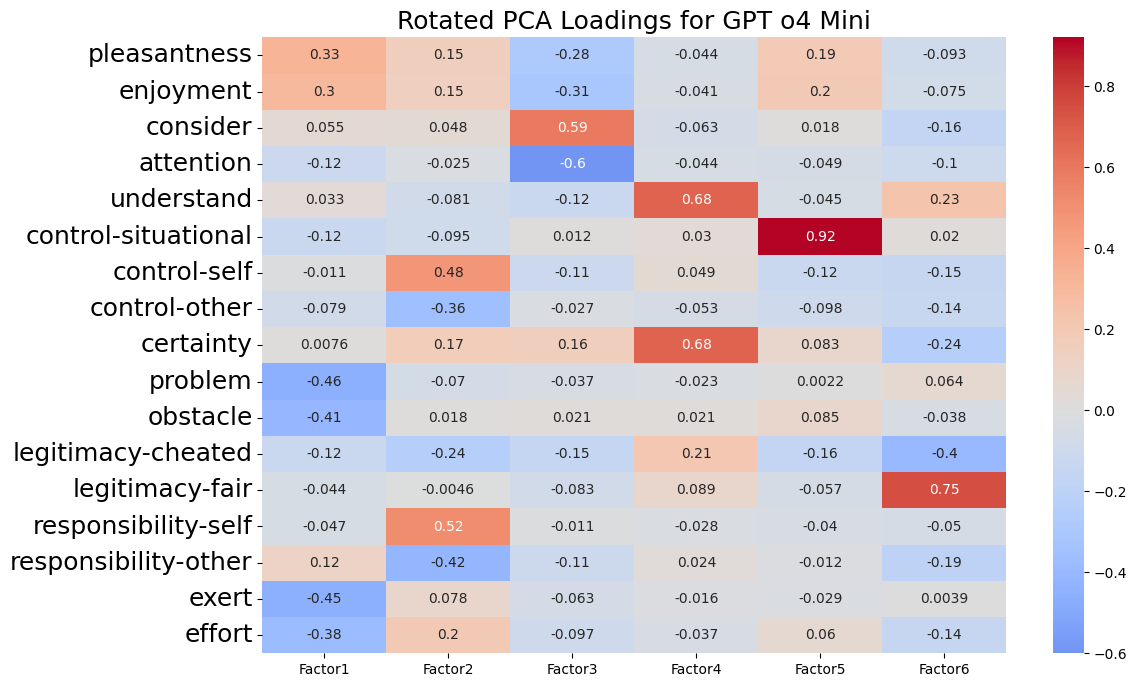

                           Factor1  \
0   (problem, -0.4596415128961961)   
1     (exert, -0.4541133584510698)   
2  (obstacle, -0.4126099210808812)   

                                        Factor2  \
0     (responsibility-self, 0.5150101587654426)   
1           (control-self, 0.48043458238181735)   
2  (responsibility-other, -0.41925093678770947)   

                             Factor3  \
0   (attention, -0.6006350517622905)   
1     (consider, 0.5919519572347891)   
2  (enjoyment, -0.31123467402633553)   

                                    Factor4  \
0          (understand, 0.6826422243104177)   
1           (certainty, 0.6789360739273238)   
2  (legitimacy-cheated, 0.2132637265191541)   

                                     Factor5  \
0  (control-situational, 0.9215614597218745)   
1           (enjoyment, 0.19881835166933962)   
2          (pleasantness, 0.186091221525882)   

                                     Factor6  
0      (legitimacy-fair, 0.7542025874333314)  
1  (l

In [18]:
# PCA analysis for GPT 
gpt_dict, gpt_emotion = get_appraisal_data("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/gpt_with_emotion_vanilla.jsonl")
gpt_df = process_df(gpt_dict, gpt_emotion)
gpt_rotated_df = pca(gpt_df, "GPT o4 Mini")
# gpt_rotated_df.to_csv("gpt_pca_varimax.csv")
top_features = top_features_per_factor(gpt_rotated_df)
print(top_features)

In [19]:
# Dimensions for GPT (by taking the top 2 dominant for each factor):
# 1. Lack of problem, or exertion, or absence of obstacle.
# 2. High self-responsibility.
# 3. Low attention, low consideration.
# 4. High understanding, high certainty.
# 5. High situational control.
# 6. High perceived fairness.

explained_variance_gpt = [0.32813223, 0.21416302, 0.11791629, 0.08619107, 0.04919336, 0.03532325]
# explained_variance_gpt.append(1 - sum(explained_variance_gpt))
factor_gpt = ["PR, EF, PL", "RES, CON", "ENG, PL", "UND, CE", "CON", "PF"]

Null values: 
pleasantness            12
enjoyment                8
consider                 7
attention                9
understand               3
control-situational      6
control-self            10
control-other            3
certainty                8
problem                  9
obstacle                 2
legitimacy-cheated       3
legitimacy-fair         11
responsibility-self      7
responsibility-other     4
exert                    6
effort                   4
dtype: int64
Filling with Zeroes:
   pleasantness  enjoyment  consider  attention  understand  \
0           5.0       11.0       1.0        5.0        11.0   
1           5.0       10.0       2.0        5.0         9.0   
2           5.0       10.0       1.0        5.0        10.0   
3           5.0       10.0       2.0        5.0        10.0   
4           5.0       10.0       2.0        5.0        10.0   

   control-situational  control-self  control-other  certainty  problem  \
0                  1.0          10.0   

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_48809/3561297153.py:58: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_filled.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)


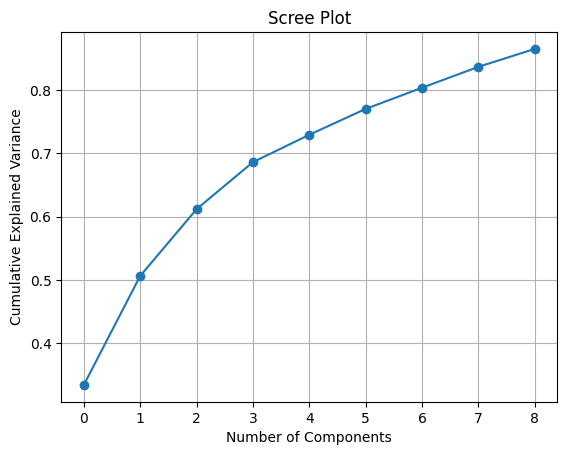

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness          0.464063 -0.014079 -0.000799 -0.062292  0.045884   
enjoyment             0.480769 -0.096329  0.023919 -0.116680 -0.004612   
consider              0.015875 -0.071634  0.007405  0.040776  0.932807   
attention             0.202707  0.061774 -0.047023 -0.810026 -0.068646   
understand           -0.072886  0.008272  0.060205 -0.024963  0.025382   
control-situational   0.017081  0.031477 -0.009848 -0.008513  0.019283   
control-self          0.063152 -0.042566 -0.075298  0.005195 -0.052518   
control-other        -0.014737 -0.558651 -0.053803  0.000359  0.118783   
certainty             0.056650  0.043753  0.906877  0.003370  0.019344   
problem              -0.411477  0.074760 -0.224870 -0.199234  0.153217   
obstacle             -0.207477  0.023656  0.174874 -0.084156  0.047958   
legitimacy-cheated   -0.359563 -0.176345  0.201574 -0.045259 -0.130276   
legitimacy-fair       0.343050  0.2093

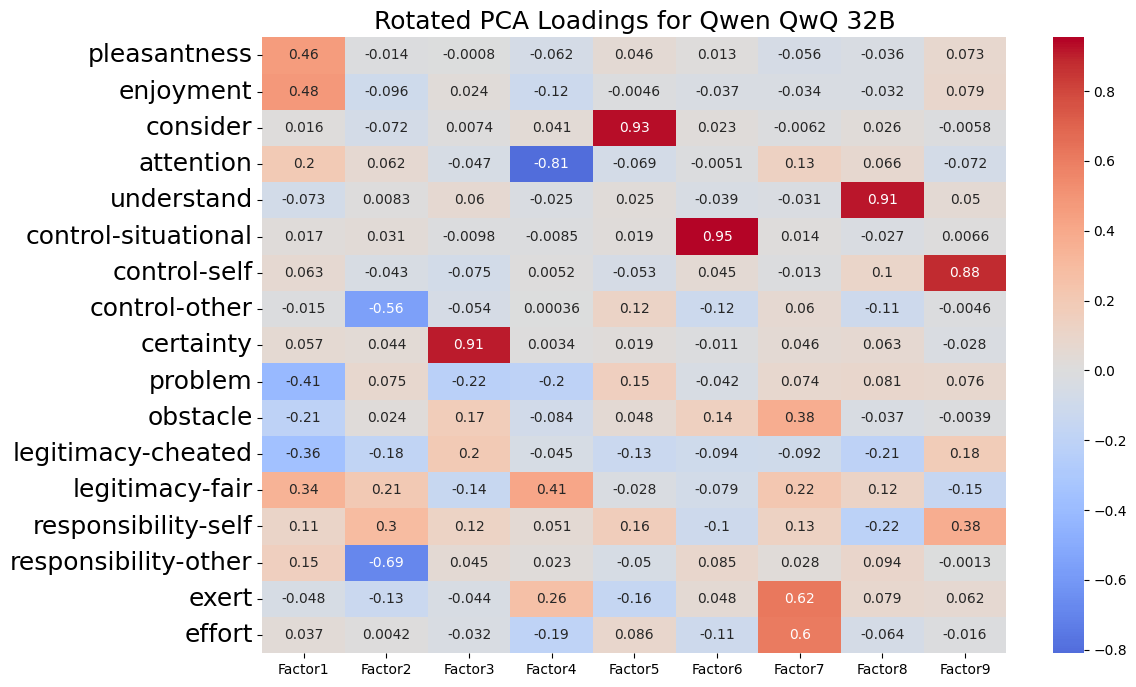

                              Factor1  \
0    (enjoyment, 0.48076862255995895)   
1  (pleasantness, 0.4640629244432521)   
2      (problem, -0.4114769169179913)   

                                       Factor2  \
0  (responsibility-other, -0.6906170280218804)   
1         (control-other, -0.5586514980768265)   
2   (responsibility-self, 0.29886778642460343)   

                                     Factor3  \
0            (certainty, 0.9068768109271929)   
1            (problem, -0.22487025726364665)   
2  (legitimacy-cheated, 0.20157411170191195)   

                                  Factor4  \
0        (attention, -0.8100257118727173)   
1  (legitimacy-fair, 0.41071843660503593)   
2             (exert, 0.2593624747943643)   

                                     Factor5  \
0             (consider, 0.9328066532613448)   
1  (responsibility-self, 0.1628123283870172)   
2              (exert, -0.15781500648606905)   

                                  Factor6                         F

In [22]:
# PCA analysis for Qwen QwQ
qwq_dict, qwq_emotion = get_appraisal_data("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/qwq_with_emotion_vanilla.jsonl")
qwq_df = process_df(qwq_dict, qwq_emotion)
qwq_rotated_df = pca(qwq_df, "Qwen QwQ 32B")
# qwq_rotated_df.to_csv("qwq_pca_varimax.csv")
top_features = top_features_per_factor(qwq_rotated_df)
print(top_features)

In [63]:
qwq_df.to_csv("./results_new/qwq_pca_new.csv")

In [20]:
# Top 6 factors for QwQ: 
# 1. Highly pleasant, highly engaged. 
# 2. High self-responsibility, low other responsibility.
# 3. Low effort, highly certain. 
# 4. High situational control, low self control. 
# 5. High understanding, high self control, high certainty.
# 6. Lack of problem, obstacle. 

explained_variance_qwq = [0.18568684, 0.09642794, 0.08188291, 0.07096485, 0.06626532, 0.05643409]
# explained_variance_qwq.append(1 - sum(explained_variance_qwq))
factor_qwq = ["CE, PF, PL", "EF, CE, PR", "UND, CON, CE", "ENG", "RES, CON, CE", "CON"]

Null values: 
pleasantness            0
enjoyment               0
consider                1
attention               1
understand              0
control-situational     0
control-self            0
control-other           0
certainty               0
problem                 0
obstacle                1
legitimacy-cheated      0
legitimacy-fair         1
responsibility-self     0
responsibility-other    0
exert                   0
effort                  0
dtype: int64
Filling with Zeroes:
  pleasantness enjoyment consider attention understand  control-situational  \
0            5        11        1         5         11                    2   
1            5        11        1         5         10                    7   
2            5        11        2         5         11                    3   
3            5        11        2         5         11                    3   
4            5        11        2         5         11                    3   

   control-self control-other certa

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_8068/3561297153.py:58: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_filled.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)


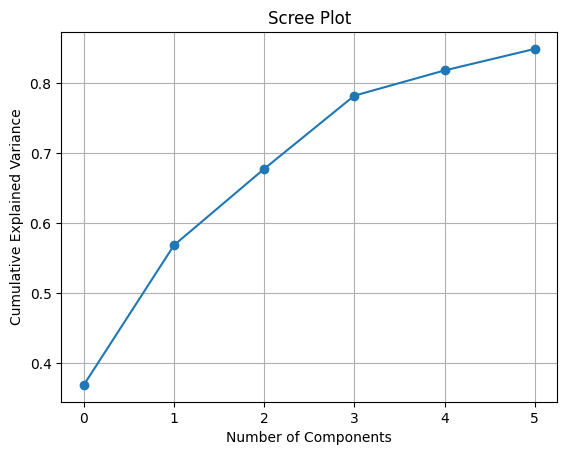

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness          0.378628  0.040654  0.161376 -0.073608  0.025716   
enjoyment             0.371148  0.071830  0.168793 -0.025798  0.032491   
consider              0.065192  0.096576 -0.721043 -0.092077  0.018971   
attention             0.084075  0.030129  0.600508 -0.041063  0.001568   
understand            0.180293  0.062154  0.094636  0.540199 -0.005536   
control-situational   0.013756 -0.055155 -0.015500  0.037973  0.968488   
control-self          0.029346  0.533983  0.010867  0.077710 -0.070084   
control-other        -0.143294 -0.382302  0.100473 -0.004453  0.070488   
certainty            -0.128655  0.021267 -0.078728  0.778777  0.037522   
problem              -0.383778  0.017785  0.117546 -0.034230  0.038570   
obstacle             -0.405060  0.010455  0.035012 -0.062763  0.001320   
legitimacy-cheated   -0.191571 -0.059231  0.049465  0.192098 -0.105246   
legitimacy-fair       0.285078  0.2302

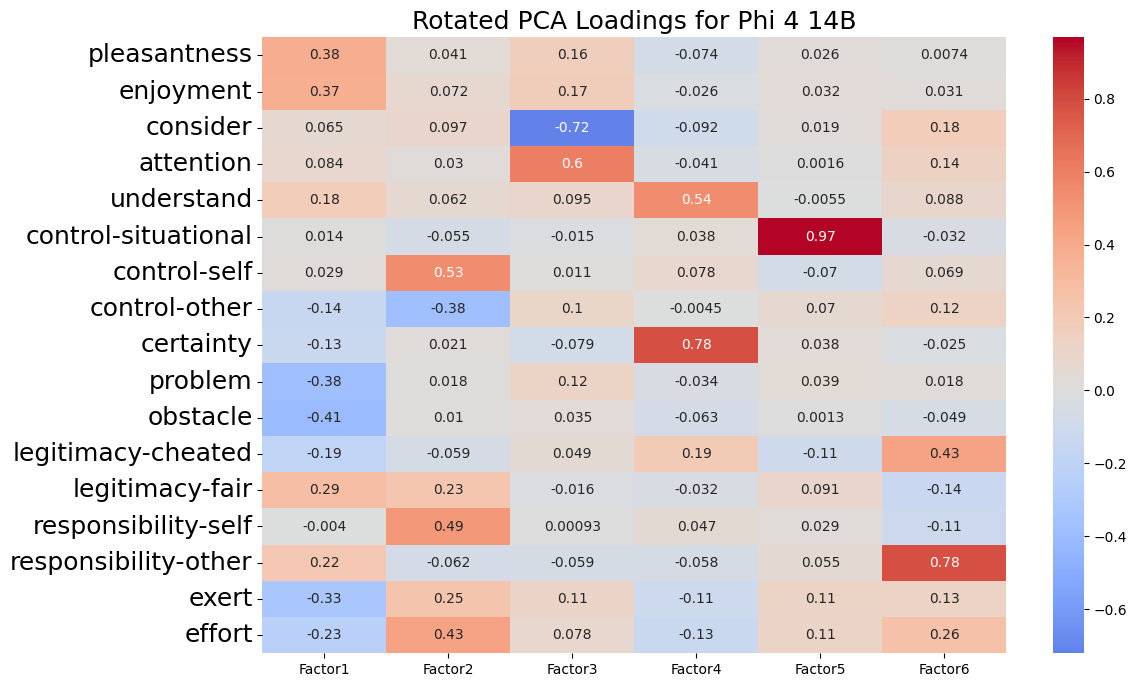

                               Factor1  \
0     (obstacle, -0.40505994506932474)   
1       (problem, -0.3837782938546324)   
2  (pleasantness, 0.37862831178054096)   

                                     Factor2  \
0         (control-self, 0.5339829259506016)   
1  (responsibility-self, 0.4894840078488514)   
2               (effort, 0.4278092894400246)   

                            Factor3                                   Factor4  \
0   (consider, -0.7210434412443303)           (certainty, 0.7787774834349828)   
1   (attention, 0.6005075153068559)          (understand, 0.5401989319621419)   
2  (enjoyment, 0.16879323742234303)  (legitimacy-cheated, 0.1920983643998495)   

                                     Factor5  \
0  (control-situational, 0.9684881733253049)   
1               (exert, 0.11139986978185401)   
2              (effort, 0.10741826613892687)   

                                      Factor6  
0  (responsibility-other, 0.7805733391600982)  
1   (legitimacy-cheated,

In [21]:
# PCA analysis for Phi 4
phi_dict, phi_emotion = get_appraisal_data("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/phi_4_with_emotion_vanilla.jsonl")
phi_df = process_df(phi_dict, phi_emotion)
phi_rotated_df = pca(phi_df, "Phi 4 14B")
# phi_rotated_df.to_csv("phi_pca_varimax.csv")
top_features = top_features_per_factor(phi_rotated_df)
print(top_features)

In [22]:
# Top 6 factors for Phi 4: 
# 1. lack of obstacle or problem.
# 2. high self-responsibility or control. 
# 3. high attention, engagement, consideration.
# 4. high certainty.
# 5. high situational control, high effort and exertion.
# 6. high other responsibility, lack of perceieved fairness.

explained_variance_phi = [0.36923169, 0.19932605, 0.10895465, 0.10441475, 0.03601619, 0.03067931]
# explained_variance_phi.append(1 - sum(explained_variance_phi))
factor_phi = ["PR, PL, EF", "CON, RES, EF", "ENG", "CE, UND", "CON", "RES, PF"]

Null values: 
pleasantness              7
enjoyment                21
consider                 72
attention                15
understand               45
control-situational      55
control-self             36
control-other            37
certainty                47
problem                  66
obstacle                 15
legitimacy-cheated       28
legitimacy-fair          51
responsibility-self      85
responsibility-other     51
exert                   120
effort                   59
dtype: int64
Filling with Zeroes:
   pleasantness  enjoyment  consider  attention  understand  \
0           5.0        9.0       3.0        4.0         8.0   
1           5.0       11.0       5.0        4.0         9.0   
2           5.0        9.0       5.0        5.0         9.0   
3           5.0       10.0       3.0        8.0        11.0   
4           5.0       11.0       2.0        4.0        11.0   

   control-situational  control-self  control-other  certainty  problem  \
0                  3.0

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_8068/3561297153.py:58: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_filled.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)


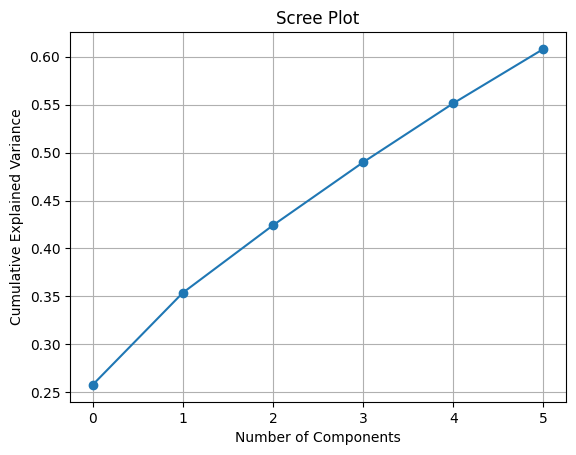

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness          0.448780 -0.091822  0.005624 -0.024145  0.009994   
enjoyment             0.429299  0.051821  0.081963  0.014843 -0.021482   
consider              0.083420 -0.082187 -0.055356 -0.083686  0.757240   
attention             0.381703 -0.156018 -0.282003  0.436378  0.048567   
understand            0.078505  0.556698 -0.025382 -0.153759 -0.161918   
control-situational  -0.177963 -0.221562  0.031350  0.568694 -0.198539   
control-self          0.281419  0.048844  0.438965  0.083677  0.115682   
control-other        -0.262006 -0.117236 -0.023969 -0.028866  0.183563   
certainty             0.015596  0.586738  0.024761  0.076876  0.024252   
problem              -0.128000  0.241283  0.028738 -0.026678  0.313560   
obstacle             -0.212040 -0.066941  0.110105  0.126294  0.322423   
legitimacy-cheated   -0.380509 -0.014479  0.046913  0.123648  0.013428   
legitimacy-fair       0.161248  0.0961

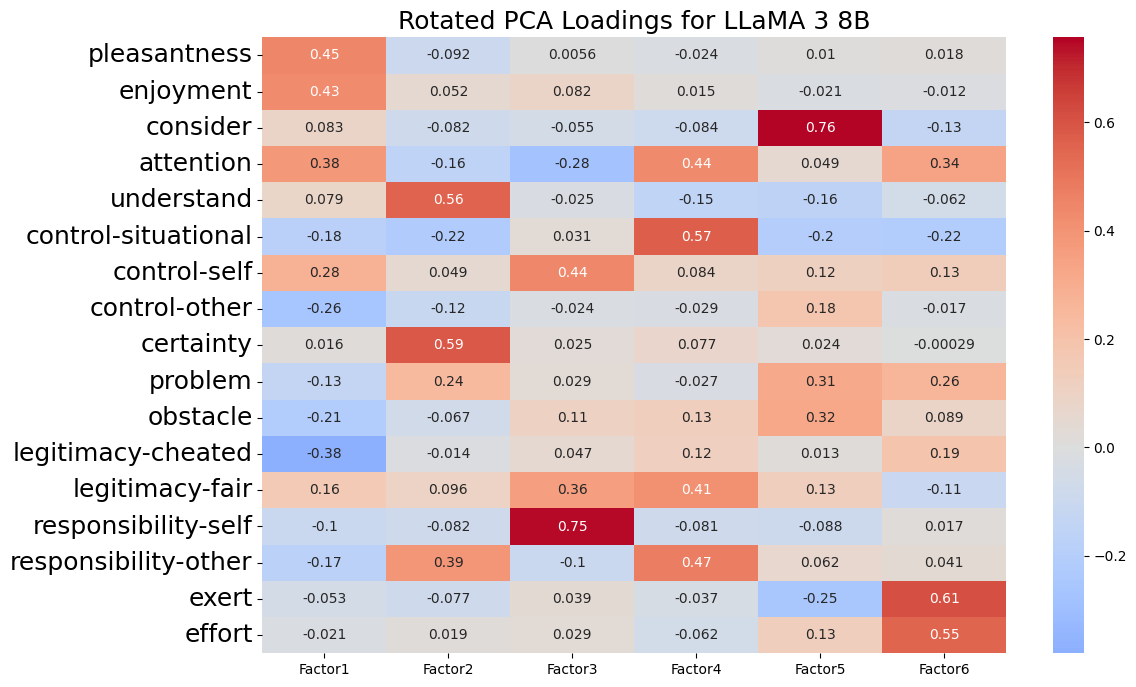

                               Factor1  \
0  (pleasantness, 0.44877966864616886)   
1      (enjoyment, 0.4292986981053265)   
2      (attention, 0.3817032726899677)   

                                       Factor2  \
0              (certainty, 0.5867376288947421)   
1             (understand, 0.5566977740884642)   
2  (responsibility-other, 0.39140391209173353)   

                                     Factor3  \
0  (responsibility-self, 0.7464615448801564)   
1        (control-self, 0.43896478803317585)   
2      (legitimacy-fair, 0.3606719856620219)   

                                      Factor4  \
0   (control-situational, 0.5686935613036578)   
1  (responsibility-other, 0.4745922861586808)   
2            (attention, 0.43637807994119093)   

                           Factor5                          Factor6  
0   (consider, 0.7572404986671868)      (exert, 0.6071280593668684)  
1  (obstacle, 0.32242339193041936)     (effort, 0.5521393260549381)  
2    (problem, 0.3135602739528

In [23]:
# PCA analysis for llama 
llama_dict, llama_emotion = get_appraisal_data("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/llama_3_8b_with_emotion_vanilla.jsonl")
llama_df = process_df(llama_dict, llama_emotion)
llama_rotated_df = pca(llama_df, "LLaMA 3 8B")
# llama_rotated_df.to_csv("llama_pca_varimax.csv")
top_features = top_features_per_factor(llama_rotated_df)
print(top_features)

In [24]:
# The top 6 factors for Llama: 
# 1. lack of fairness / high pleasantness, high enjoyment
# 2. High other responsibility (AND high certainty)
# 3. High attention, high situational or other control 
# 4. High perceived fairness, high self control/responsibility
# 5. Lack of effort or exertion, lack of considering/engagement
# 6. High understanding (also high effort and problem)


explained_variance_llama = [0.21595889, 0.08999371, 0.07467734, 0.06903393, 0.06009623, 0.0580315]
# explained_variance_llama.append(1 - sum(explained_variance_llama))
factor_llama = ["PL, ENG, PF", "CE, UND, RES", "RES, CON", "RES, CON, ENG", "ENG, PR", "EF, ENG"]

Null values: 
pleasantness            0
enjoyment               0
consider                1
attention               0
understand              1
control-situational     0
control-self            1
control-other           0
certainty               1
problem                 2
obstacle                1
legitimacy-cheated      1
legitimacy-fair         0
responsibility-self     0
responsibility-other    0
exert                   0
effort                  0
dtype: int64
Filling with Zeroes:
   pleasantness  enjoyment  consider  attention  understand  \
0             5         11       1.0          5        11.0   
1             5         11       1.0          5         7.0   
2             5         11       1.0          5        11.0   
3             5         11       1.0          5        11.0   
4             5         10       1.0          5        10.0   

   control-situational  control-self  control-other  certainty  problem  \
0                    2          11.0              1     

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_8068/3561297153.py:58: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_filled.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)


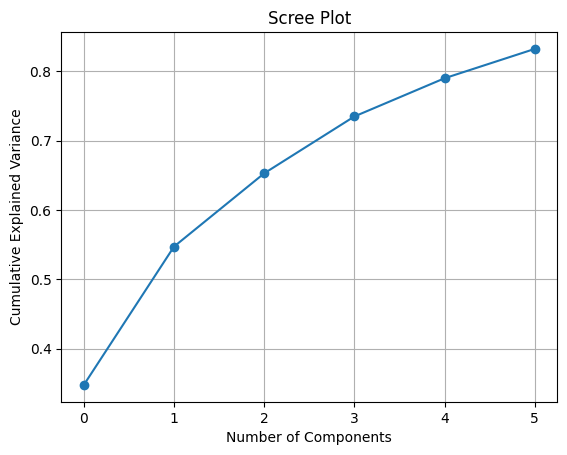

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness          0.274371 -0.027800  0.209399  0.042025  0.167426   
enjoyment             0.260998 -0.049458  0.235605  0.013361  0.173182   
consider             -0.048943  0.049446 -0.577012  0.002397 -0.062295   
attention            -0.098478  0.087268  0.667699  0.005982 -0.101483   
understand           -0.033096  0.114232  0.106312  0.742405 -0.014635   
control-situational  -0.118324  0.016450  0.016305  0.009113  0.886675   
control-self         -0.035493 -0.391479  0.156765  0.124252 -0.208849   
control-other        -0.046063  0.392197 -0.020902 -0.087980 -0.154101   
certainty             0.043581 -0.219831 -0.161333  0.603506  0.025701   
problem              -0.490770  0.088579 -0.061712  0.075822  0.074461   
obstacle             -0.509950  0.046045  0.001362  0.057351  0.096590   
legitimacy-cheated   -0.119905  0.254857  0.065295  0.123533 -0.199857   
legitimacy-fair      -0.085329 -0.0446

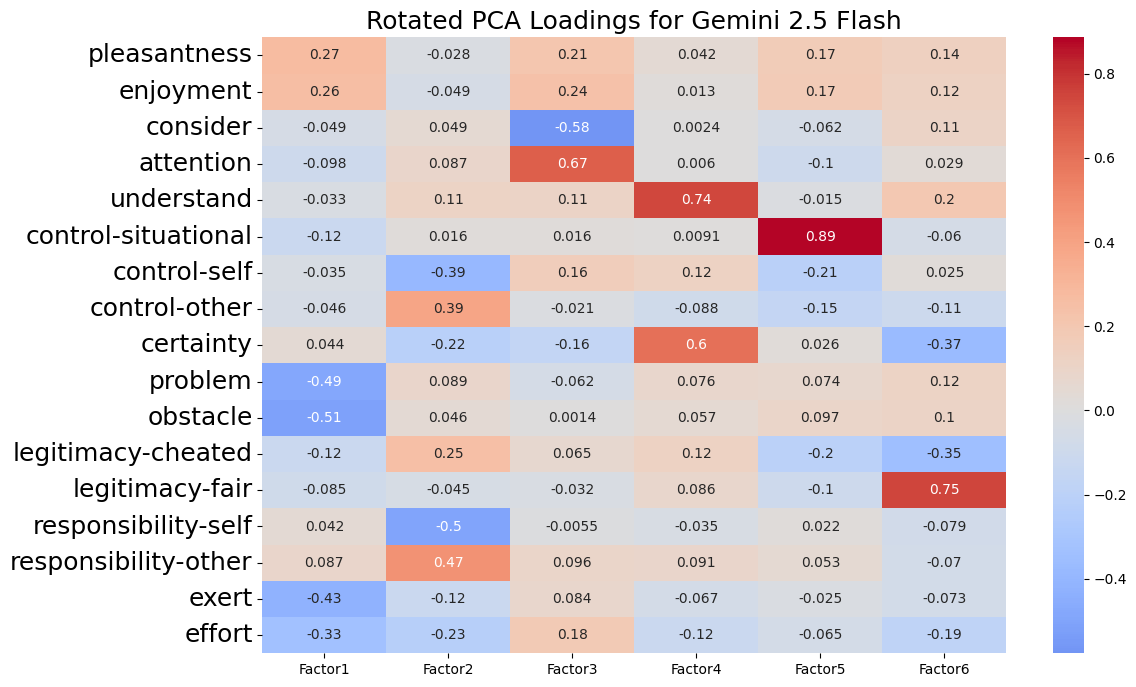

                           Factor1  \
0  (obstacle, -0.5099499238805896)   
1    (problem, -0.490769817344419)   
2     (exert, -0.4265051110475703)   

                                      Factor2  \
0  (responsibility-self, -0.5020169779695641)   
1  (responsibility-other, 0.4736318757765388)   
2         (control-other, 0.3921970507562462)   

                            Factor3                              Factor4  \
0   (attention, 0.6676985477304603)      (understand, 0.742405235305817)   
1   (consider, -0.5770115535614118)      (certainty, 0.6035061374821461)   
2  (enjoyment, 0.23560508519227344)  (control-self, 0.12425205593965193)   

                                      Factor5  \
0   (control-situational, 0.8866746011421088)   
1        (control-self, -0.20884936533428983)   
2  (legitimacy-cheated, -0.19985703915141106)   

                                      Factor6  
0       (legitimacy-fair, 0.7485506782214124)  
1           (certainty, -0.37414086478721675)  
2  (

In [25]:
# PCA analysis for Gemini
gemini_dict, gemini_emotion = get_appraisal_data("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/gemini_2_5_flash_with_emotion_vanilla.jsonl")
gemini_df = process_df(gemini_dict, gemini_emotion)
gemini_rotated_df = pca(gemini_df, "Gemini 2.5 Flash")
# phi_rotated_df.to_csv("phi_pca_varimax.csv")
top_features = top_features_per_factor(gemini_rotated_df)
print(top_features)

In [26]:
# Top 6 Factors for Gemini: 
# 1. Lack of problem, obstacle, exertion
# 2. low Self-responsibility, high other responsibility or control
# 3. high attention, high engagement
# 4. high understanding, high certainty
# 5. high situational control
# 6. high perceived legitimacy/fairness

explained_variance_gemini = [0.34749434, 0.19961396, 0.10575265, 0.08206911, 0.05515061, 0.04233205]
# explained_variance_gemini.append(1 - sum(explained_variance_gemini))
factor_gemini = ["PR, EF", "RES, CON", "ENG", "UND, CE", "CON", "PF, CE"]

Null values: 
pleasantness            0
enjoyment               0
consider                0
attention               0
understand              0
control-situational     0
control-self            0
control-other           0
certainty               0
problem                 0
obstacle                0
legitimacy-cheated      0
legitimacy-fair         0
responsibility-self     0
responsibility-other    0
exert                   0
effort                  0
dtype: int64
Filling with Zeroes:
   pleasantness  enjoyment  consider  attention  understand  \
0             5         10         2          5          10   
1             5         10         1          5           4   
2             5         11         2          5          10   
3             5         11         1          5          11   
4             5         11         1          5           9   

   control-situational  control-self  control-other  certainty  problem  \
0                    4            10              1     

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_8068/3561297153.py:58: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_filled.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)


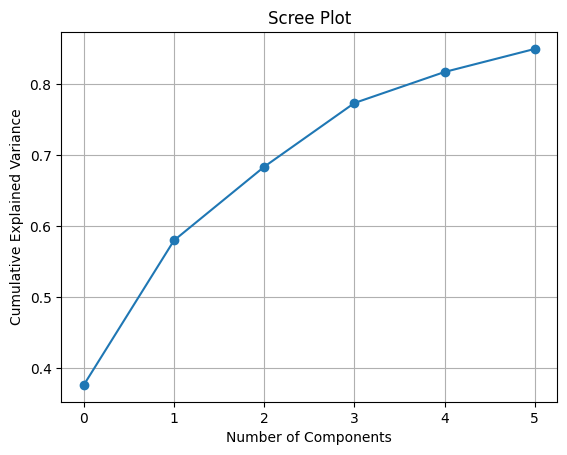

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness          0.294865  0.018504 -0.000052 -0.063244  0.054831   
enjoyment             0.289286  0.034683  0.021093 -0.060832  0.040144   
consider              0.291522 -0.007816  0.305541  0.179578  0.033510   
attention             0.047941  0.025934  0.088134  0.310369  0.020357   
understand            0.008654 -0.060924 -0.553766 -0.027153 -0.056403   
control-situational  -0.083538 -0.517981  0.192309  0.013028  0.583561   
control-self          0.031508  0.558850 -0.000072 -0.017206  0.003811   
control-other        -0.190052 -0.158976 -0.022109 -0.078966 -0.551336   
certainty            -0.041588  0.143882 -0.625221  0.301970  0.260396   
problem              -0.516074 -0.021739 -0.006065 -0.018402 -0.014792   
obstacle             -0.523167 -0.029628  0.000063 -0.029772  0.012452   
legitimacy-cheated   -0.012201 -0.027136 -0.024209  0.529298 -0.134695   
legitimacy-fair       0.031186  0.0424

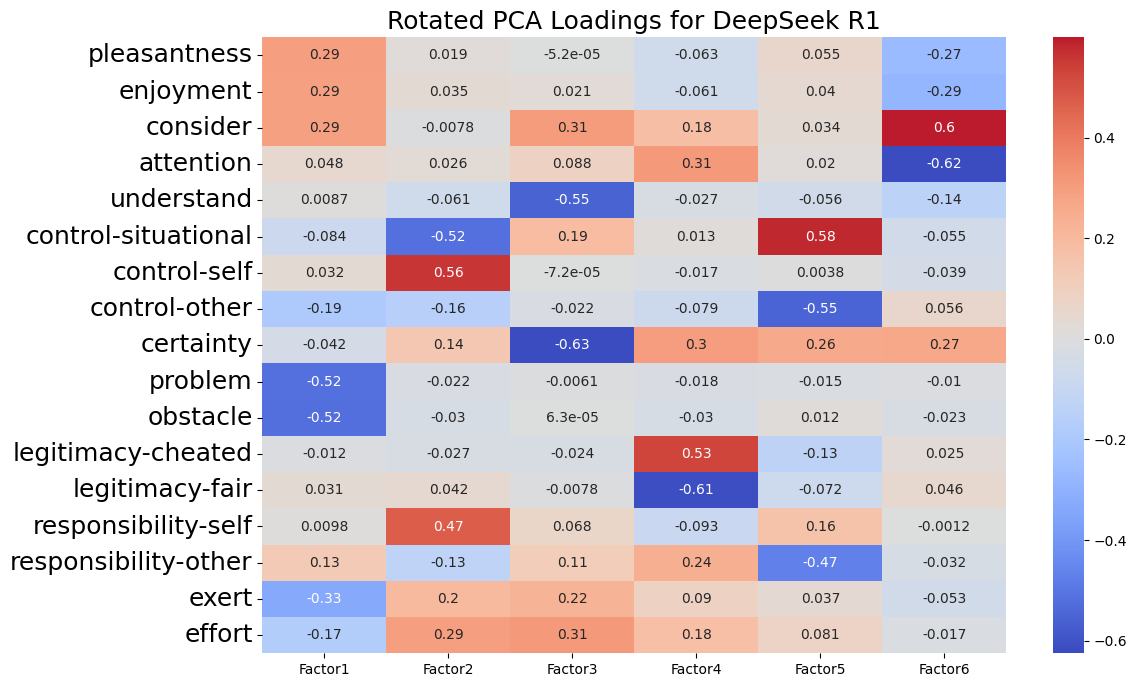

                           Factor1  \
0  (obstacle, -0.5231674501162165)   
1   (problem, -0.5160737194603401)   
2    (exert, -0.33095911436956393)   

                                      Factor2  \
0          (control-self, 0.5588498825879394)   
1  (control-situational, -0.5179811903368827)   
2   (responsibility-self, 0.4707400824875677)   

                            Factor3                                   Factor4  \
0  (certainty, -0.6252213357371428)    (legitimacy-fair, -0.6138431262231797)   
1  (understand, -0.553766048719042)  (legitimacy-cheated, 0.5292977923849657)   
2      (effort, 0.3081015832221148)           (attention, 0.3103691286665047)   

                                        Factor5  \
0     (control-situational, 0.5835607992406849)   
1          (control-other, -0.5513356027220012)   
2  (responsibility-other, -0.46986933281061827)   

                            Factor6  
0  (attention, -0.6187338213163464)  
1    (consider, 0.5992322911226718)  
2  (en

In [27]:
# PCA analysis for DeepSeek
ds_dict, ds_emotion = get_appraisal_data("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/deepseek_r1_with_emotion_vanilla.jsonl")
ds_df = process_df(ds_dict, ds_emotion)
ds_rotated_df = pca(ds_df, "DeepSeek R1")
# phi_rotated_df.to_csv("phi_pca_varimax.csv")
top_features = top_features_per_factor(ds_rotated_df)
print(top_features)

In [28]:
explained_variance_ds = [0.37593903, 0.20349814, 0.10370456, 0.08976971, 0.04371877, 0.03248634]
# explained_variance_ds.append(1 - sum(explained_variance_ds))
factor_ds = ["PR, EF", "RES, CON", "CE, UND, ENG, EF", "PF, ENG, CE", "RES, CON", "ENG, PL"]

In [29]:
explained_variance_human = [0.251, 0.165, 0.115, 0.102, 0.10, 0.062]
# explained_variance_human.append(1 - sum(explained_variance_human))
# factor_human = ["PL, PR, PF", "RES, CON, PF", "UND, CE", "ENG", "EF", "CON", ""]
factor_human = ["PL, PR, PF", "RES, CON, PF", "UND, CE", "ENG", "EF", "CON"]

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_8068/2639493596.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(np.linspace(0.0, 1.0, 5).tolist(), fontsize=20)


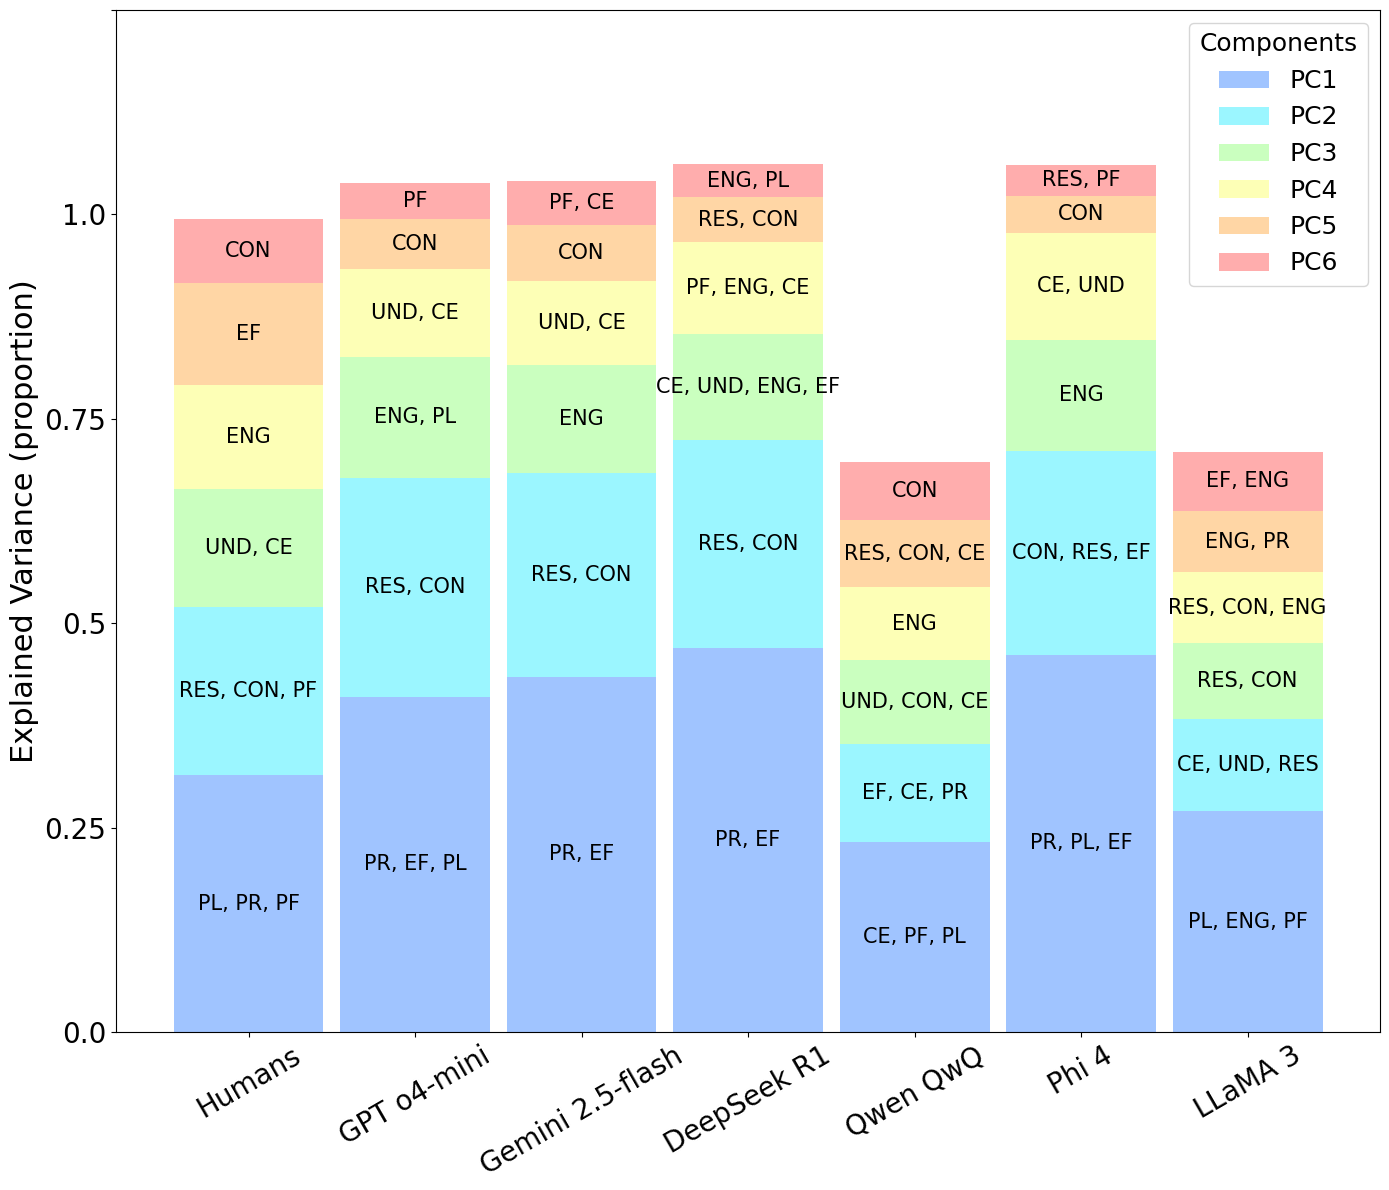

In [32]:
models_data = {
    "Humans": (explained_variance_human, factor_human),
    "GPT o4-mini": (explained_variance_gpt, factor_gpt),
    "Gemini 2.5-flash": (explained_variance_gemini, factor_gemini),
    "DeepSeek R1": (explained_variance_ds, factor_ds),
    "Qwen QwQ": (explained_variance_qwq, factor_qwq),
    "Phi 4": (explained_variance_phi, factor_phi),
    "LLaMA 3": (explained_variance_llama, factor_llama)
}

plot_pca_rankings(models_data)

### With Emotions, No Persona: Pleasant and Unpleasant PCA

In [63]:
pleasant_emotions = ['happiness', 'hope', 'surprise', 'pride', 'interest', 'challenge']
unpleasant_emotions = ['disgust', 'boredom', 'shame', 'guilt', 'fear', 'sadness', 'anger', 'contempt', 'frustration']

Explained Variance Ratio = [0.34385808 0.24397858 0.06588596 0.06388252 0.05118576 0.04302534]
Total explained Variance = 0.811816237251764


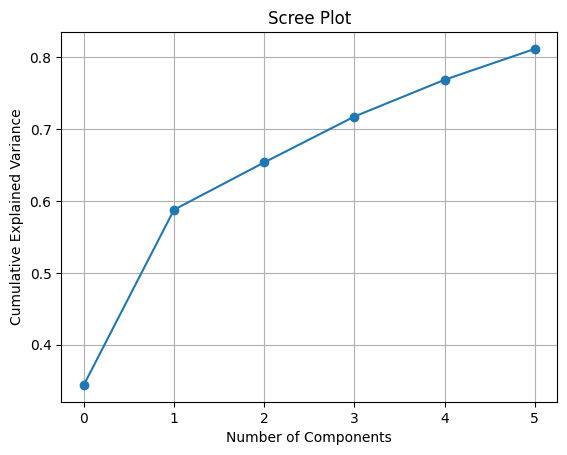

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness         -0.137456  0.064181 -0.024410 -0.189845 -0.098859   
enjoyment            -0.093457  0.036240  0.063650  0.092274 -0.070430   
consider             -0.045088  0.023354  0.019604  0.026787  0.926275   
attention            -0.127174  0.053082 -0.201905  0.613730  0.047499   
understand           -0.017890 -0.019847  0.011936  0.047063  0.207717   
control-situational   0.167868 -0.240354  0.823921  0.012651  0.050108   
control-self          0.118892  0.418192 -0.098919  0.026785 -0.020494   
control-other         0.410604 -0.559034 -0.454761  0.008691  0.098673   
certainty             0.091093  0.170898  0.128318  0.050307 -0.076980   
problem               0.446997 -0.049144  0.059147 -0.016444 -0.004901   
obstacle              0.445147  0.077498  0.074379  0.004476  0.016019   
legitimacy-cheated    0.083417 -0.023873  0.119782  0.682666 -0.034677   
legitimacy-fair       0.052438 -0.0737

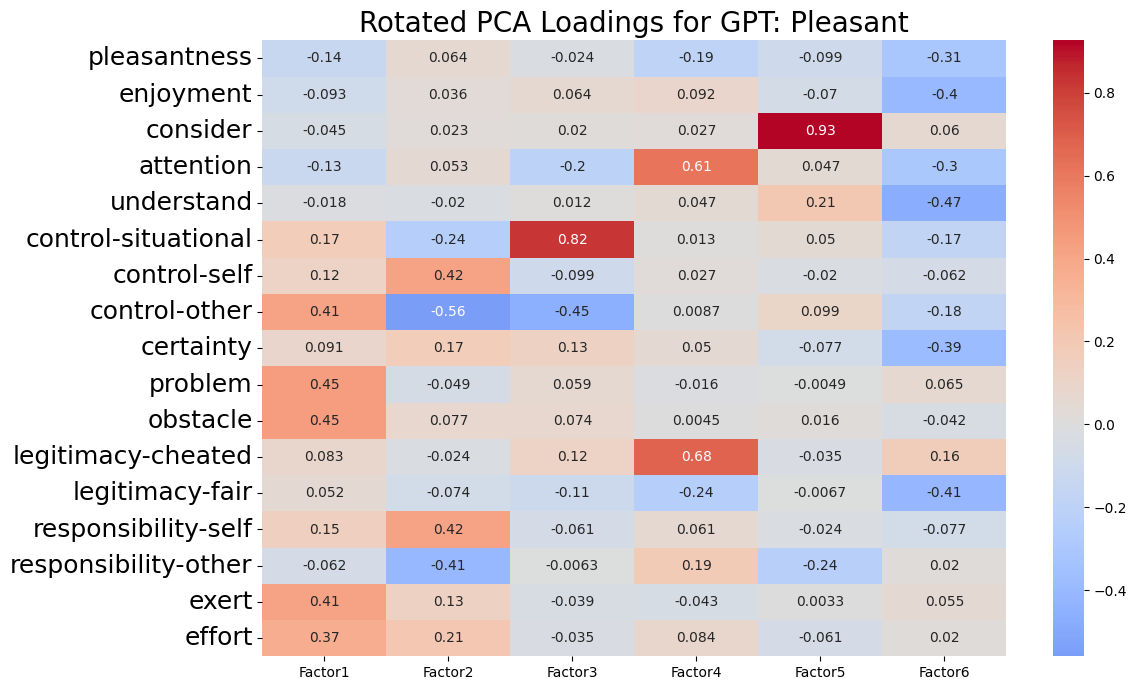

                                Factor1  \
0        (problem, 0.44699662414715224)   
1       (obstacle, 0.44514667660283846)   
2  (control-other, 0.41060399409024767)   

                                     Factor2  \
0        (control-other, -0.559033601003079)   
1        (control-self, 0.41819175112967516)   
2  (responsibility-self, 0.4152678365028733)   

                                     Factor3  \
0  (control-situational, 0.8239206613719057)   
1      (control-other, -0.45476066042350444)   
2          (attention, -0.20190538525168808)   

                                    Factor4  \
0  (legitimacy-cheated, 0.6826661992609355)   
1           (attention, 0.6137295182835896)   
2    (legitimacy-fair, -0.2430853860677226)   

                                        Factor5  \
0                (consider, 0.9262751977992407)   
1  (responsibility-other, -0.23957424874109148)   
2              (understand, 0.2077171517715733)   

                                   Factor6  
0 

In [65]:
# calculate pleasant and unpleasant for GPT 
gpt_p = gpt_df[gpt_df["emotion"].isin(pleasant_emotions)]
gpt_up = gpt_df[gpt_df["emotion"].isin(unpleasant_emotions)]
gpt_p_rotated_df = pca(gpt_p, "GPT: Pleasant")
# phi_rotated_df.to_csv("phi_pca_varimax.csv")
top_features = top_features_per_factor(gpt_p_rotated_df)
print(top_features)

In [66]:
gpt_p_explained_variance = [0.34385808, 0.24397858, 0.06588596, 0.06388252, 0.05118576, 0.04302534]
gpt_p_factors = ["CON, PR, EF", "CON, RES", "CON", "ENG, PF", "ENG", "PL, UND, CER, PF"]

Explained Variance Ratio = [0.2574086  0.2307482  0.10834958 0.06853937 0.05179542 0.05009351]
Total explained Variance = 0.7669346799701104


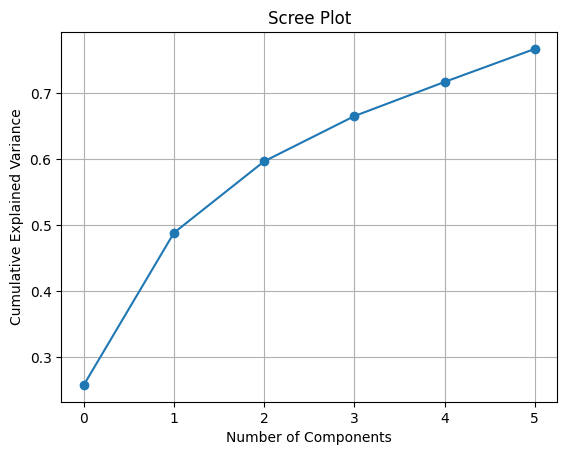

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness         -0.376273  0.221515 -0.159221  0.293948 -0.504213   
enjoyment            -0.016239  0.000179  0.104710  0.817763  0.067609   
consider              0.019521  0.038611  0.016012 -0.142720 -0.149101   
attention             0.197177  0.014296 -0.056719 -0.144839 -0.116837   
understand           -0.075945 -0.044218  0.546429  0.036386  0.200480   
control-situational   0.213315 -0.122096 -0.282930  0.267568  0.075607   
control-self          0.029209  0.417617  0.103258 -0.132981 -0.039515   
control-other         0.002147 -0.342837 -0.106171 -0.046793 -0.244657   
certainty             0.057901  0.120729  0.675864  0.041095 -0.150465   
problem               0.459353 -0.032847  0.012338 -0.032923  0.010363   
obstacle              0.393365 -0.017999 -0.039998  0.298068 -0.145994   
legitimacy-cheated    0.113873 -0.307942  0.308721  0.033384 -0.246402   
legitimacy-fair      -0.096333  0.0539

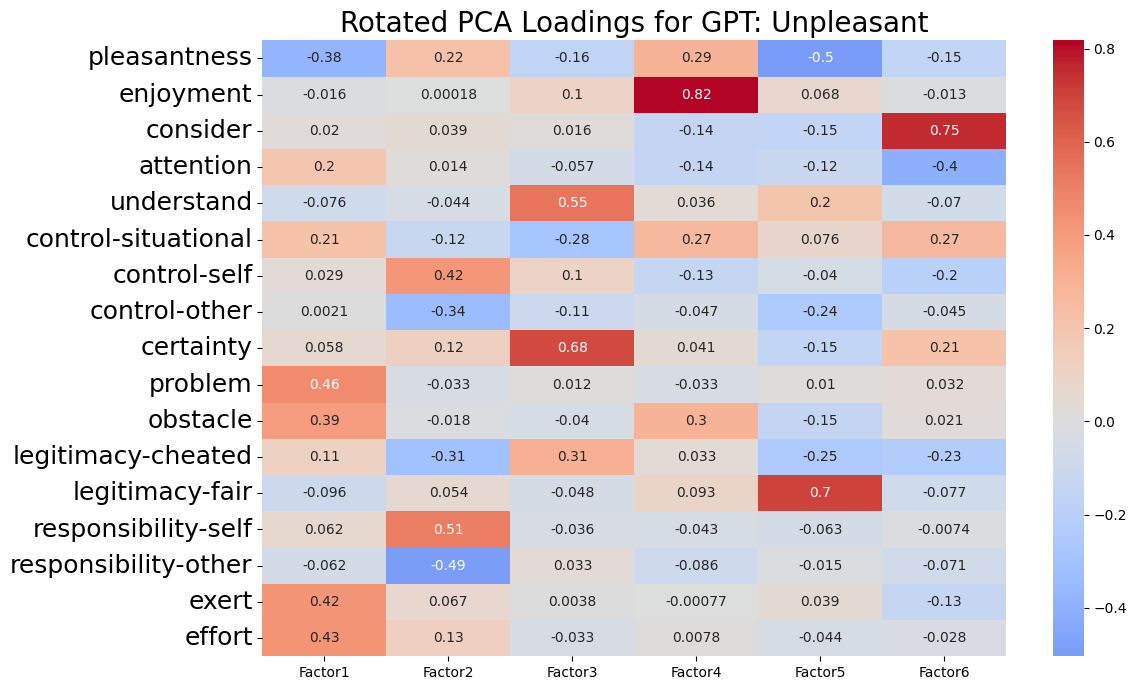

                         Factor1                                      Factor2  \
0  (problem, 0.4593533649092391)     (responsibility-self, 0.514252441903969)   
1   (effort, 0.4334036456164311)  (responsibility-other, -0.4912420787028875)   
2    (exert, 0.4241408377168846)           (control-self, 0.4176168314836172)   

                                     Factor3  \
0             (certainty, 0.675863660319335)   
1           (understand, 0.5464287046236778)   
2  (legitimacy-cheated, 0.30872132262476826)   

                              Factor4  \
0      (enjoyment, 0.817762529699364)   
1     (obstacle, 0.29806762774938156)   
2  (pleasantness, 0.2939478710313011)   

                                     Factor5  \
0       (legitimacy-fair, 0.696780875271018)   
1        (pleasantness, -0.5042125360366086)   
2  (legitimacy-cheated, -0.2464023389301468)   

                                      Factor6  
0              (consider, 0.7544505053724333)  
1            (attention, -0.

In [67]:
gpt_up_rotated_df = pca(gpt_up, "GPT: Unpleasant")
# phi_rotated_df.to_csv("phi_pca_varimax.csv")
top_features = top_features_per_factor(gpt_up_rotated_df)
print(top_features)

In [68]:
gpt_up_explained_variance = [0.2574086,  0.2307482,  0.10834958, 0.06853937, 0.05179542, 0.05009351]
gpt_up_factors = ["PL, PR, EF", "CON, RES", "UND, CER", "PL, PR", "PL, PF", "ENG"]

Explained Variance Ratio = [0.29603509 0.22738743 0.08354161 0.07359633 0.05639004 0.0523273 ]
Total explained Variance = 0.7892778052435782


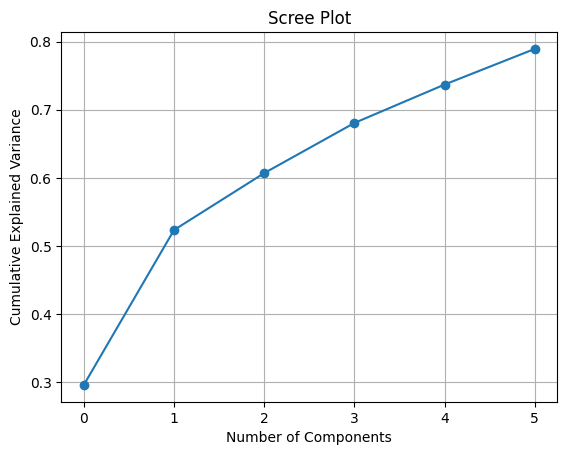

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness          0.463656 -0.041093 -0.032063  0.069955 -0.073298   
enjoyment             0.443788  0.005194  0.026419  0.090372  0.065775   
consider             -0.349739  0.097906 -0.258089 -0.257198 -0.196477   
attention            -0.044837  0.011749 -0.027947 -0.054658  0.911655   
understand           -0.032493 -0.035948 -0.083923  0.648323  0.087007   
control-situational  -0.013362 -0.248976  0.218074  0.081361  0.016837   
control-self         -0.004321  0.455659  0.006523  0.096107  0.075840   
control-other        -0.184669 -0.210305  0.049137 -0.110694 -0.081906   
certainty             0.035056  0.110645  0.008982  0.590672 -0.118152   
problem               0.010735 -0.092004  0.575556  0.016599 -0.001565   
obstacle              0.022307  0.008561  0.550944 -0.019930 -0.095643   
legitimacy-cheated   -0.419997 -0.037997  0.034066  0.268420 -0.142168   
legitimacy-fair       0.477369  0.0288

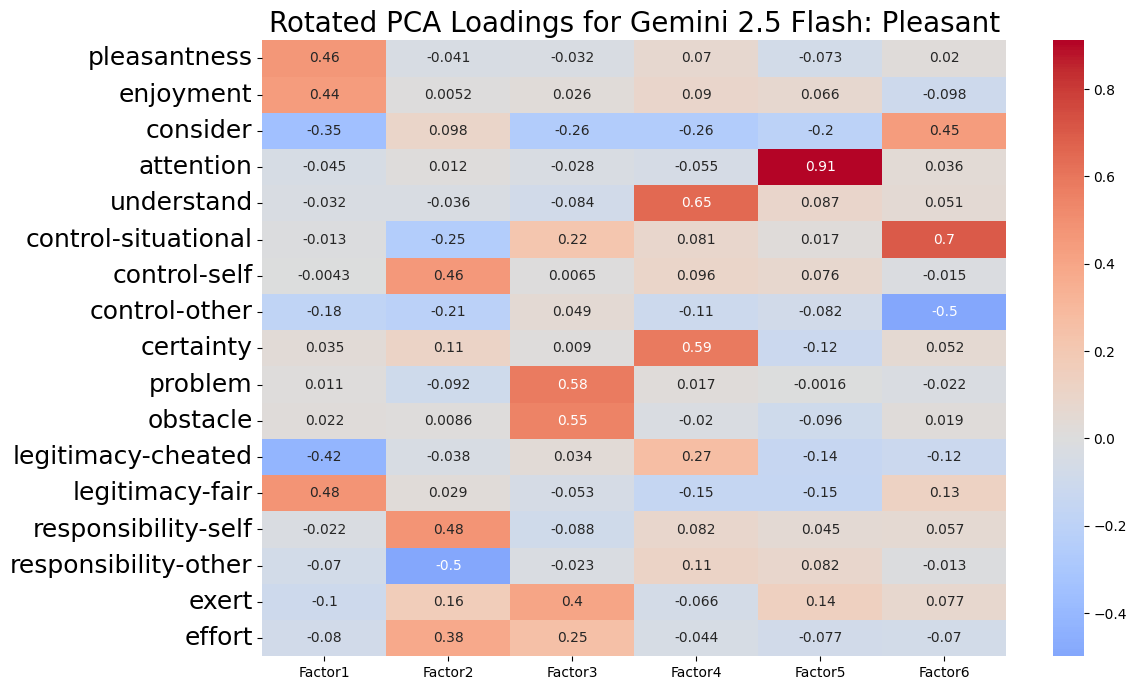

                                 Factor1  \
0  (legitimacy-fair, 0.4773688689041506)   
1     (pleasantness, 0.4636563341578457)   
2       (enjoyment, 0.44378750217090623)   

                                       Factor2  \
0  (responsibility-other, -0.4990812615794773)   
1    (responsibility-self, 0.4774383164261841)   
2          (control-self, 0.45565899407458826)   

                          Factor3                                   Factor4  \
0   (problem, 0.5755558925354752)          (understand, 0.6483227170857764)   
1  (obstacle, 0.5509436972486003)           (certainty, 0.5906722887770937)   
2    (exert, 0.40239958619229343)  (legitimacy-cheated, 0.2684203282825696)   

                                   Factor5  \
0          (attention, 0.9116547418182508)   
1          (consider, -0.1964772905565231)   
2  (legitimacy-fair, -0.15426775782438662)   

                                     Factor6  
0  (control-situational, 0.7005765463160079)  
1       (control-other, -0

In [69]:
# calculate pleasant and unpleasant for GPT 
gemini_p = gemini_df[gemini_df["emotion"].isin(pleasant_emotions)]
gemini_up = gemini_df[gemini_df["emotion"].isin(unpleasant_emotions)]
gemini_p_rotated_df = pca(gemini_p, "Gemini 2.5 Flash: Pleasant")
# phi_rotated_df.to_csv("phi_pca_varimax.csv")
top_features = top_features_per_factor(gemini_p_rotated_df)
print(top_features)

In [70]:
gemini_p_explained_variance = [0.29603509, 0.22738743, 0.08354161, 0.07359633, 0.05639004, 0.0523273]
gemini_p_factors = ["PL, ENG, PF", "CON, RES, EF", "PR, EF", "UND, CER", "ENG", "ENG, CON"]

Explained Variance Ratio = [0.24907149 0.20182288 0.11786548 0.08500682 0.06288364 0.05832947]
Total explained Variance = 0.7749797849132309


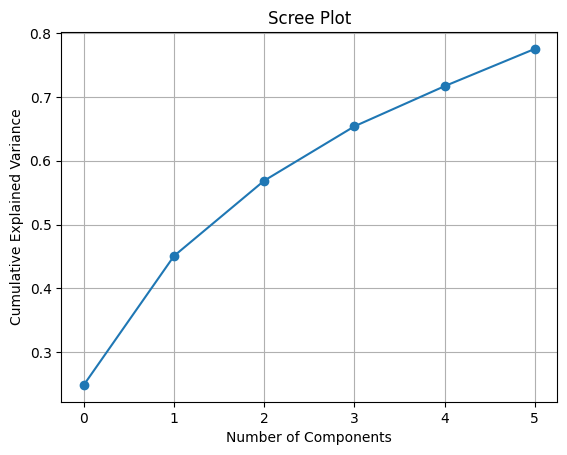

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness         -0.006266  0.099565  0.046001  0.639919  0.011330   
enjoyment            -0.069492 -0.000903 -0.139500  0.657110 -0.026915   
consider              0.053465 -0.599150  0.057649 -0.082671 -0.011823   
attention             0.104373  0.593822  0.180852  0.070082  0.002077   
understand            0.104673  0.004009  0.341501  0.012990  0.131384   
control-situational  -0.065383 -0.068709 -0.631475  0.079274  0.018758   
control-self         -0.319664  0.164320  0.255765 -0.013053  0.126663   
control-other         0.450629 -0.046228 -0.017828 -0.050665 -0.007620   
certainty            -0.185908 -0.028627 -0.065175 -0.049692 -0.094618   
problem               0.017793 -0.020672  0.002786  0.063620 -0.689526   
obstacle              0.002276  0.040447  0.012549 -0.061816 -0.669291   
legitimacy-cheated    0.382167  0.202574  0.013140  0.025507 -0.094099   
legitimacy-fair      -0.161526 -0.1695

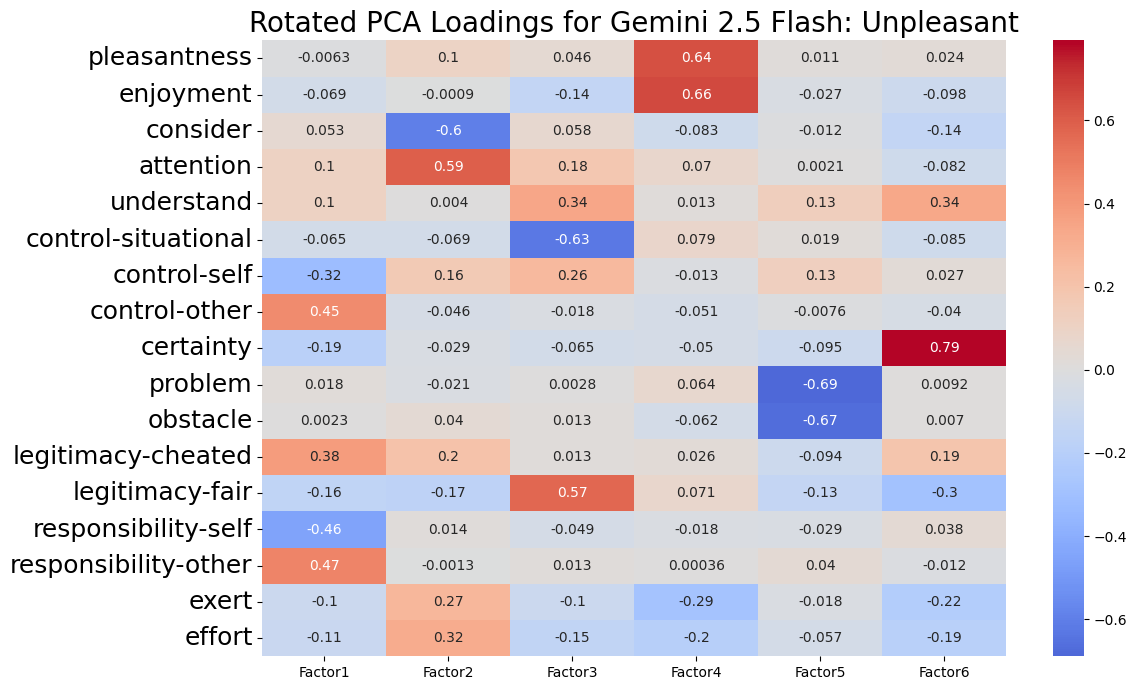

                                      Factor1  \
0   (responsibility-other, 0.469772038308146)   
1  (responsibility-self, -0.4576301051569058)   
2         (control-other, 0.4506293082468485)   

                           Factor2  \
0  (consider, -0.5991502812337316)   
1   (attention, 0.593822234938162)   
2    (effort, 0.31710580945525607)   

                                      Factor3  \
0  (control-situational, -0.6314753765623651)   
1       (legitimacy-fair, 0.5680082506424838)   
2            (understand, 0.3415008480865685)   

                              Factor4  \
0     (enjoyment, 0.6571097913945987)   
1  (pleasantness, 0.6399189850016507)   
2       (exert, -0.28548109333600147)   

                                   Factor5  \
0           (problem, -0.6895264035665748)   
1          (obstacle, -0.6692911264639705)   
2  (legitimacy-fair, -0.13430307870341046)   

                                   Factor6  
0          (certainty, 0.7930322308969652)  
1        (und

In [71]:
gemini_up_rotated_df = pca(gemini_up, "Gemini 2.5 Flash: Unpleasant")
# phi_rotated_df.to_csv("phi_pca_varimax.csv")
top_features = top_features_per_factor(gemini_up_rotated_df)
print(top_features)

In [72]:
gemini_up_explained_variance = [0.24907149, 0.20182288, 0.11786548, 0.08500682, 0.06288364, 0.05832947]
gemini_up_factors = ["CON, PF, RES", "ENG, EF", "CON, PF", "PL", "PR", "CER, UND"]

Explained Variance Ratio = [0.31839616 0.21804826 0.07890926 0.06618119 0.05713379 0.0507858 ]
Total explained Variance = 0.7894544585680501


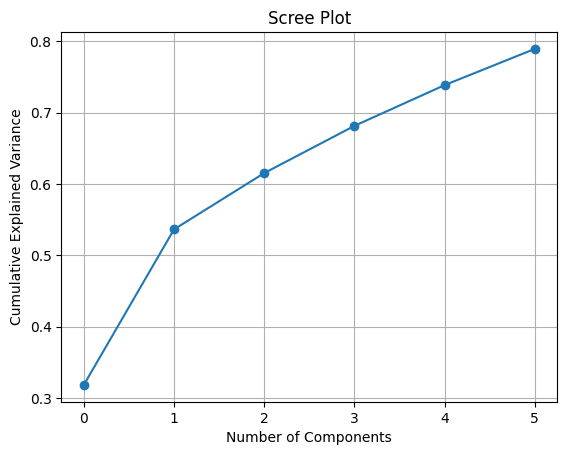

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness         -0.488317  0.008615 -0.025149  0.106363  0.008067   
enjoyment            -0.373102  0.088165 -0.012556  0.106845  0.120363   
consider              0.205207  0.217637  0.232563 -0.500410 -0.249751   
attention             0.043727  0.000245  0.055446 -0.069093  0.905747   
understand            0.044813 -0.058405  0.101485  0.602443 -0.094199   
control-situational   0.106374 -0.454645  0.474444 -0.022823 -0.083082   
control-self          0.000619  0.509172  0.012151  0.068309  0.080445   
control-other         0.051577 -0.090299 -0.645011  0.050973 -0.197232   
certainty             0.005239  0.173746  0.061698  0.475292 -0.014131   
problem               0.046347 -0.044512  0.011325 -0.001688  0.011555   
obstacle              0.017811  0.007816 -0.005867 -0.014186 -0.022160   
legitimacy-cheated    0.560153  0.035503 -0.074675  0.265626  0.023177   
legitimacy-fair      -0.492096 -0.0566

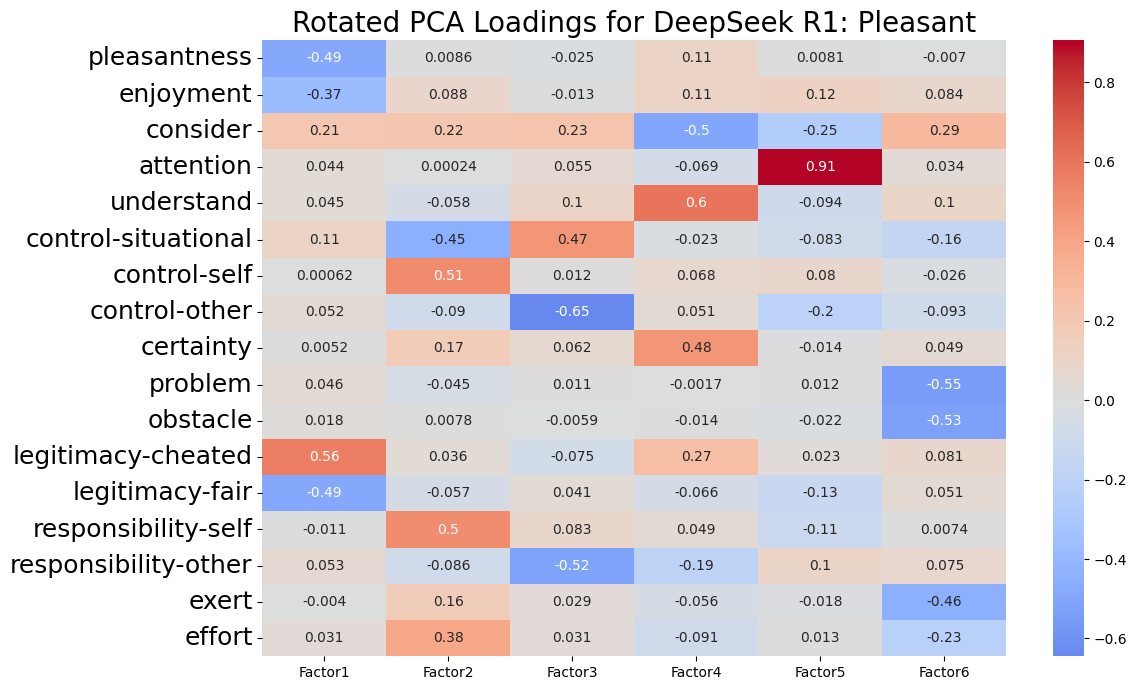

                                    Factor1  \
0  (legitimacy-cheated, 0.5601528799521266)   
1     (legitimacy-fair, -0.492096181693766)   
2      (pleasantness, -0.48831704291338146)   

                                       Factor2  \
0           (control-self, 0.5091716475993664)   
1    (responsibility-self, 0.5027647236696268)   
2  (control-situational, -0.45464473249589826)   

                                       Factor3  \
0         (control-other, -0.6450113005886033)   
1  (responsibility-other, -0.5202070743290318)   
2   (control-situational, 0.47444363740730033)   

                            Factor4                                Factor5  \
0  (understand, 0.6024425046693022)        (attention, 0.9057473611432195)   
1   (consider, -0.5004100272169835)       (consider, -0.24975077912853685)   
2   (certainty, 0.4752922451819296)  (control-other, -0.19723244514009172)   

                           Factor6  
0    (problem, -0.550330880365804)  
1  (obstacle, -0.53217

In [76]:
# calculate pleasant and unpleasant for GPT 
ds_p = ds_df[ds_df["emotion"].isin(pleasant_emotions)]
ds_up = ds_df[ds_df["emotion"].isin(unpleasant_emotions)]
ds_p_rotated_df = pca(ds_p, "DeepSeek R1: Pleasant")
# phi_rotated_df.to_csv("phi_pca_varimax.csv")
top_features = top_features_per_factor(ds_p_rotated_df)
print(top_features)

In [77]:
ds_p_explained_variance = [0.29603509, 0.22738743, 0.08354161, 0.07359633, 0.05639004, 0.0523273]
ds_p_factors = ["PL, PF", "CON, RES, EF", "CON, RES", "UND, CER, ENG", "ENG", "ENG, CON"]
# here the control in the final component is other and situational control 

Explained Variance Ratio = [0.25516562 0.22446366 0.12187511 0.0697461  0.05326726 0.051845  ]
Total explained Variance = 0.7763627453203581


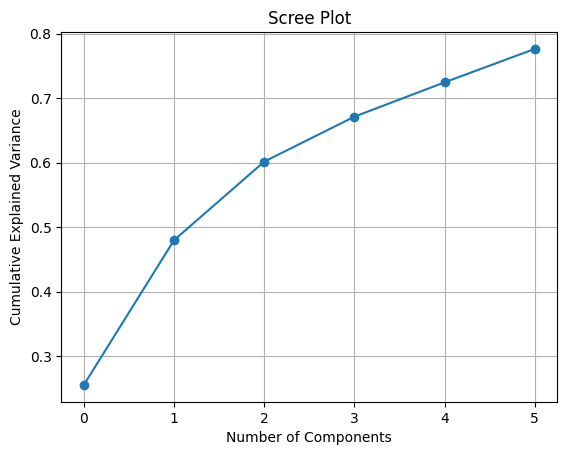

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness         -0.027831  0.003045  0.040783  0.638386 -0.050974   
enjoyment            -0.024592  0.016473 -0.017300  0.723275  0.040780   
consider              0.203985  0.141074  0.112189 -0.050492  0.644873   
attention             0.111538  0.152221  0.126204 -0.023848 -0.683798   
understand           -0.466813  0.076819 -0.131663 -0.111913 -0.150283   
control-situational   0.069602 -0.123718  0.585155  0.092551  0.055656   
control-self          0.203868 -0.199112 -0.413473  0.021386 -0.111679   
control-other        -0.142547  0.346647  0.074692 -0.033715  0.157500   
certainty            -0.157106  0.075658 -0.541638  0.038778  0.188828   
problem               0.051368  0.002203 -0.058092  0.011061 -0.019501   
obstacle              0.070173  0.001010  0.084251 -0.026739 -0.008283   
legitimacy-cheated    0.106990  0.511297 -0.153561  0.017802  0.006462   
legitimacy-fair      -0.247345 -0.4632

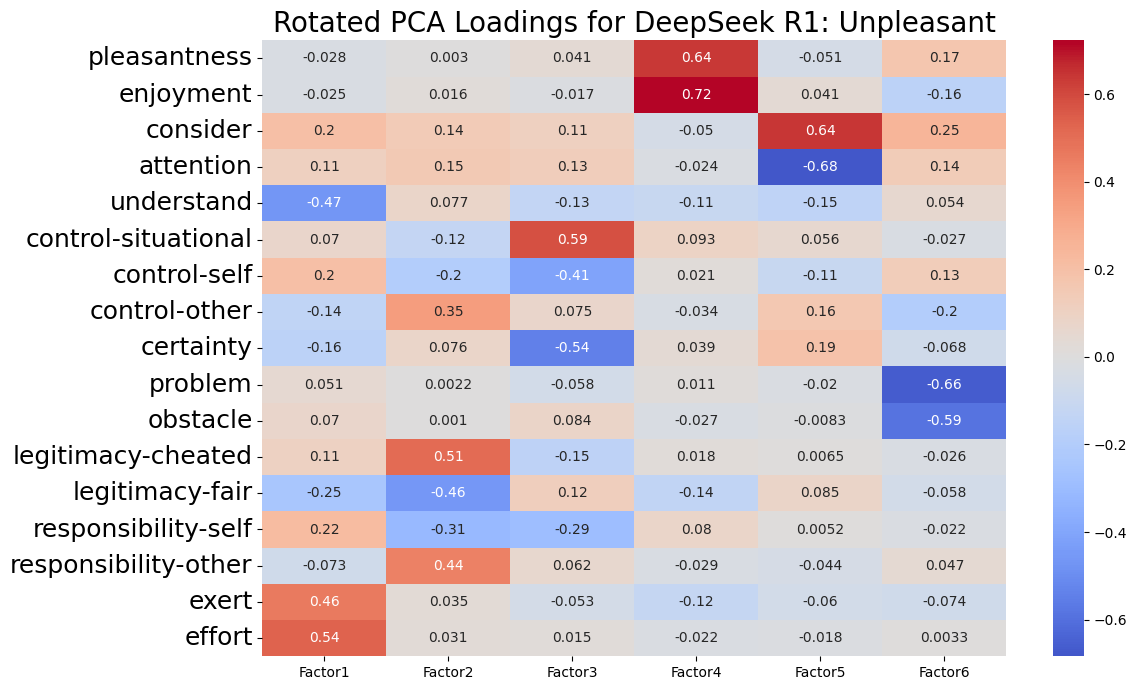

                              Factor1  \
0        (effort, 0.5358087346250178)   
1  (understand, -0.46681299789025793)   
2        (exert, 0.46313796211453945)   

                                       Factor2  \
0       (legitimacy-cheated, 0.51129699890389)   
1      (legitimacy-fair, -0.46325549196091603)   
2  (responsibility-other, 0.43949934117488293)   

                                     Factor3  \
0  (control-situational, 0.5851548349621267)   
1           (certainty, -0.5416376615951349)   
2         (control-self, -0.413473314150828)   

                                   Factor4                           Factor5  \
0           (enjoyment, 0.723274580633746)  (attention, -0.6837983097780297)   
1       (pleasantness, 0.6383862889172196)    (consider, 0.6448730930986449)   
2  (legitimacy-fair, -0.13695129175357426)  (certainty, 0.18882753676392322)   

                           Factor6  
0   (problem, -0.6648049493522135)  
1  (obstacle, -0.5871321515256146)  
2    (con

In [78]:
ds_up_rotated_df = pca(ds_up, "DeepSeek R1: Unpleasant")
# phi_rotated_df.to_csv("phi_pca_varimax.csv")
top_features = top_features_per_factor(ds_up_rotated_df)
print(top_features)

In [79]:
ds_up_explained_variance = [0.25516562, 0.22446366, 0.12187511, 0.0697461, 0.05326726, 0.051845]
ds_up_factors = ["UND, EF", "CON, PF, RES", "CON, CER", "PL", "ENG", "PR"]

Explained Variance Ratio = [0.29257101 0.21390176 0.06896216 0.0632452  0.05595865 0.04996588]
Total explained Variance = 0.7446046567229905


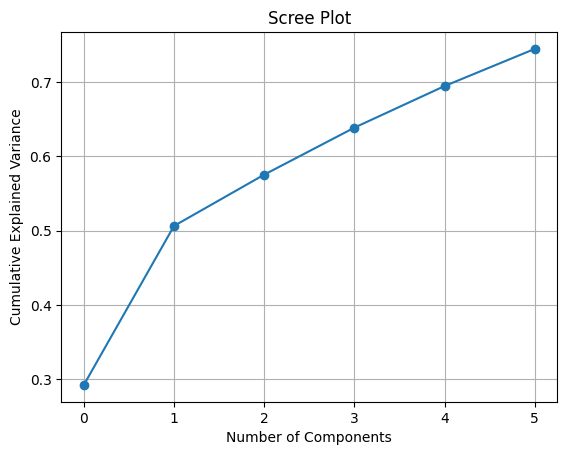

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness          0.448871 -0.050172 -0.076490  0.059356  0.219634   
enjoyment             0.462142 -0.112101  0.078647  0.002394  0.005383   
consider             -0.064060 -0.094493  0.095861  0.013917  0.093392   
attention            -0.103766 -0.043190 -0.033600  0.766284 -0.136288   
understand            0.397869  0.002112 -0.132363  0.024650  0.006590   
control-situational  -0.014189  0.130638 -0.090755 -0.011198  0.837940   
control-self          0.208191  0.329321 -0.154075  0.030916 -0.127804   
control-other         0.246832  0.034466  0.758681 -0.077520 -0.056445   
certainty             0.206564 -0.059018 -0.450333 -0.056001  0.003804   
problem              -0.152867  0.348471  0.195808  0.126862 -0.007361   
obstacle             -0.034482  0.453717 -0.036680 -0.003055  0.071936   
legitimacy-cheated   -0.167788 -0.061478 -0.047426 -0.602365 -0.151772   
legitimacy-fair       0.413393  0.0845

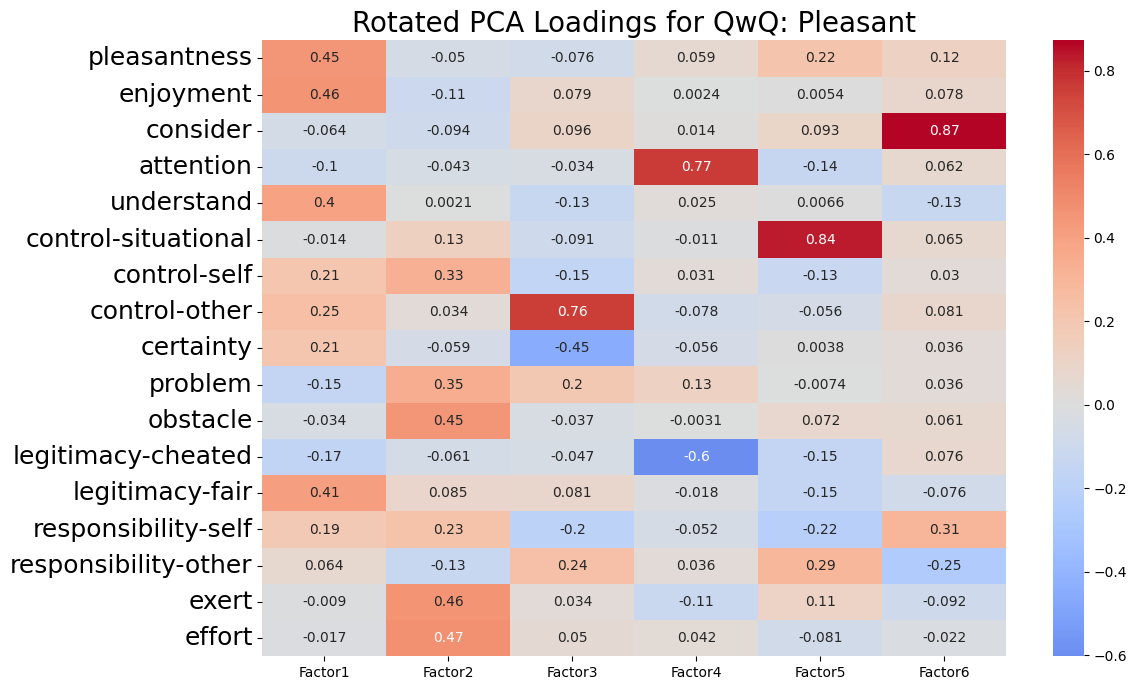

                                 Factor1                          Factor2  \
0        (enjoyment, 0.4621421174654258)    (effort, 0.47030906975572906)   
1    (pleasantness, 0.44887061083927304)     (exert, 0.46176874676646745)   
2  (legitimacy-fair, 0.4133926659996821)  (obstacle, 0.45371700909009055)   

                                      Factor3  \
0         (control-other, 0.7586810603614417)   
1            (certainty, -0.4503330068056496)   
2  (responsibility-other, 0.2435297090871734)   

                                     Factor4  \
0            (attention, 0.7662836487763656)   
1  (legitimacy-cheated, -0.6023653496231678)   
2             (problem, 0.12686190376431794)   

                                      Factor5  \
0   (control-situational, 0.8379401084152708)   
1  (responsibility-other, 0.2937171389759289)   
2         (pleasantness, 0.21963424866742212)   

                                       Factor6  
0               (consider, 0.8728768533032543)  
1    (

In [80]:
# calculate pleasant and unpleasant for GPT 
qwq_p = qwq_df[qwq_df["emotion"].isin(pleasant_emotions)]
qwq_up = qwq_df[qwq_df["emotion"].isin(unpleasant_emotions)]
qwq_p_rotated_df = pca(qwq_p, "QwQ: Pleasant")
# phi_rotated_df.to_csv("phi_pca_varimax.csv")
top_features = top_features_per_factor(qwq_p_rotated_df)
print(top_features)

In [82]:
qwq_p_explained_variance = [0.29257101, 0.21390176, 0.06896216, 0.0632452,  0.05595865, 0.04996588]
qwq_p_factors = ["PL, UND, PF", "CON, PR, EF", "CON, CER", "ENG, PF", "CON", "ENG"]

Explained Variance Ratio = [0.19309023 0.16938314 0.11457666 0.07563161 0.06981121 0.06184948]
Total explained Variance = 0.6843423346359936


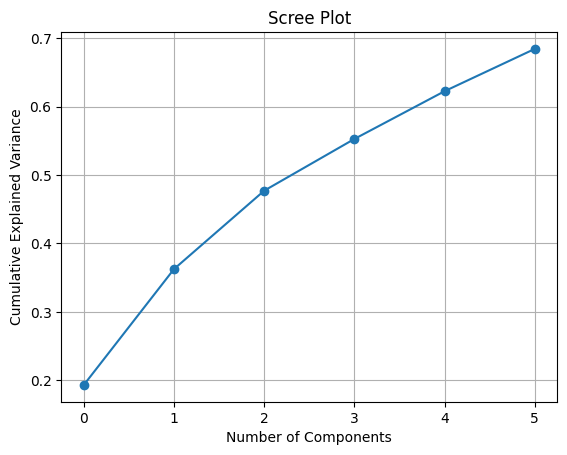

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness         -0.157972 -0.243859  0.062847  0.391720 -0.042090   
enjoyment             0.059413 -0.067723 -0.009780  0.720371  0.017623   
consider              0.058860  0.188935 -0.064670  0.163524 -0.145660   
attention             0.042561  0.193526 -0.084117  0.130012 -0.238486   
understand            0.064291 -0.168451 -0.488369 -0.171878  0.084485   
control-situational   0.045597 -0.118659  0.348468  0.036814 -0.441583   
control-self         -0.122674  0.236123 -0.526859  0.259534  0.038979   
control-other         0.478169  0.061690  0.048413  0.041644  0.006914   
certainty            -0.150785 -0.217267  0.046916 -0.126927  0.580384   
problem               0.157091  0.421057  0.001496 -0.079541  0.013869   
obstacle             -0.054329  0.120236  0.563976  0.014747  0.176787   
legitimacy-cheated    0.234922  0.145493  0.105547  0.176875  0.522764   
legitimacy-fair      -0.411569 -0.0382

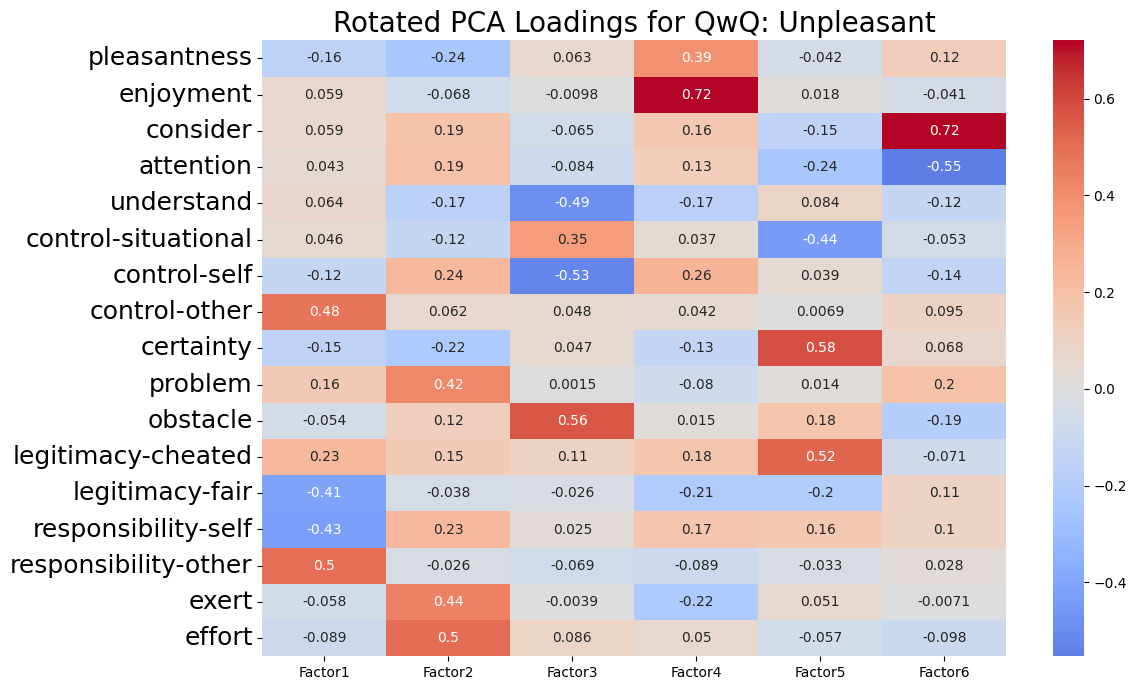

                                       Factor1                        Factor2  \
0  (responsibility-other, 0.49789588309146054)   (effort, 0.5027372957596595)   
1          (control-other, 0.4781691385492936)    (exert, 0.4401076529864652)   
2   (responsibility-self, -0.4269086294323227)  (problem, 0.4210567866276427)   

                               Factor3                              Factor4  \
0       (obstacle, 0.5639759243847704)      (enjoyment, 0.7203708456247895)   
1  (control-self, -0.5268587966399644)   (pleasantness, 0.3917196320394177)   
2    (understand, -0.4883689252665147)  (control-self, 0.25953435444810535)   

                                       Factor5  \
0              (certainty, 0.5803839041722407)   
1     (legitimacy-cheated, 0.5227638618751234)   
2  (control-situational, -0.44158259128499217)   

                            Factor6  
0    (consider, 0.7175830454573281)  
1  (attention, -0.5527772265546209)  
2     (problem, 0.1962386576081931)  


In [81]:
qwq_up_rotated_df = pca(qwq_up, "QwQ: Unpleasant")
# phi_rotated_df.to_csv("phi_pca_varimax.csv")
top_features = top_features_per_factor(qwq_up_rotated_df)
print(top_features)

In [83]:
qwq_up_explained_variance = [0.19309023, 0.16938314, 0.11457666, 0.07563161, 0.06981121, 0.06184948]
qwq_up_factors = ["CON, PF, RES", "PR, EF", "UND, CON, PR", "PL", "CON, CER, PF", "ENG"]

Explained Variance Ratio = [0.22530693 0.11089971 0.08075505 0.07474709 0.06500911 0.06205083]
Total explained Variance = 0.6187687233338638


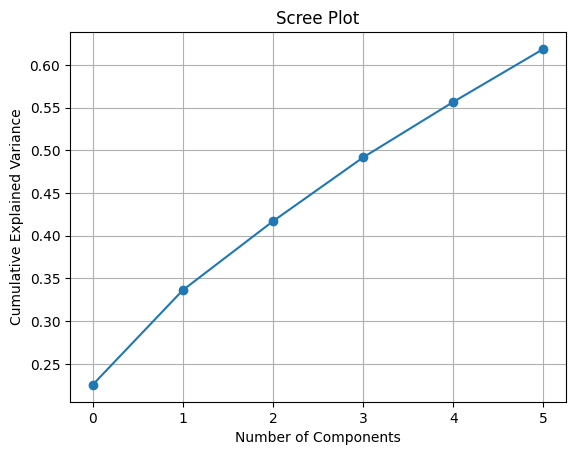

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness          0.329318  0.113481  0.000310 -0.026857  0.119822   
enjoyment             0.583655 -0.077530 -0.049021  0.110480  0.025686   
consider              0.052711  0.066183 -0.350807 -0.313594 -0.142043   
attention             0.182841  0.099080  0.612822  0.011543  0.033812   
understand            0.136423  0.060297 -0.187291  0.512831  0.128316   
control-situational  -0.104233 -0.046183  0.507019 -0.190517 -0.167145   
control-self          0.174949  0.561491  0.005547 -0.078813 -0.085703   
control-other         0.044229 -0.310881 -0.034233 -0.036838 -0.358830   
certainty            -0.057916  0.513636  0.139796  0.042831  0.154898   
problem               0.092562 -0.050168 -0.058849  0.182510 -0.459774   
obstacle             -0.001772  0.090888  0.017072 -0.109955 -0.482047   
legitimacy-cheated   -0.101455  0.015695  0.184805  0.021948 -0.374832   
legitimacy-fair       0.589395  0.0129

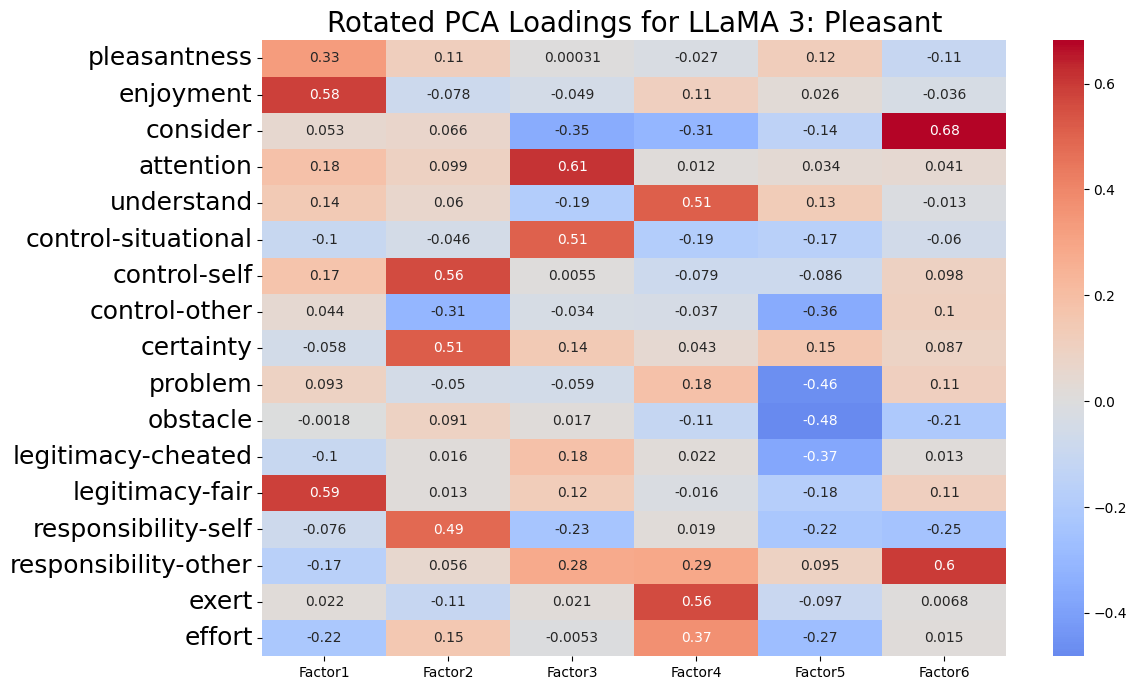

                                 Factor1  \
0  (legitimacy-fair, 0.5893951118932144)   
1        (enjoyment, 0.5836547157095164)   
2     (pleasantness, 0.3293176994861158)   

                                     Factor2  \
0         (control-self, 0.5614908017578093)   
1            (certainty, 0.5136363063270543)   
2  (responsibility-self, 0.4852792647724787)   

                                     Factor3  \
0            (attention, 0.6128224293133481)   
1  (control-situational, 0.5070186986474666)   
2           (consider, -0.35080670454506335)   

                            Factor4  \
0       (exert, 0.5617454272355176)   
1  (understand, 0.5128310316640319)   
2     (effort, 0.36862404043794356)   

                                      Factor5  \
0             (obstacle, -0.4820474166438294)   
1             (problem, -0.45977375781004265)   
2  (legitimacy-cheated, -0.37483224833747636)   

                                       Factor6  
0               (consider, 0.68171

In [84]:
# calculate pleasant and unpleasant for GPT 
llama_p = llama_df[llama_df["emotion"].isin(pleasant_emotions)]
llama_up = llama_df[llama_df["emotion"].isin(unpleasant_emotions)]
llama_p_rotated_df = pca(llama_p, "LLaMA 3: Pleasant")
# phi_rotated_df.to_csv("phi_pca_varimax.csv")
top_features = top_features_per_factor(llama_p_rotated_df)
print(top_features)

In [85]:
llama_p_explained_variance = [0.22530693, 0.11089971, 0.08075505, 0.07474709, 0.06500911, 0.06205083]
llama_p_factors = ["PL, PF", "CON, CER, RES", "ENG, CON", "ENG, UND, EF", "PR, PF", "ENG, RES"]

Explained Variance Ratio = [0.11608341 0.09763109 0.08624742 0.07479534 0.07295939 0.07018304]
Total explained Variance = 0.5178996935645268


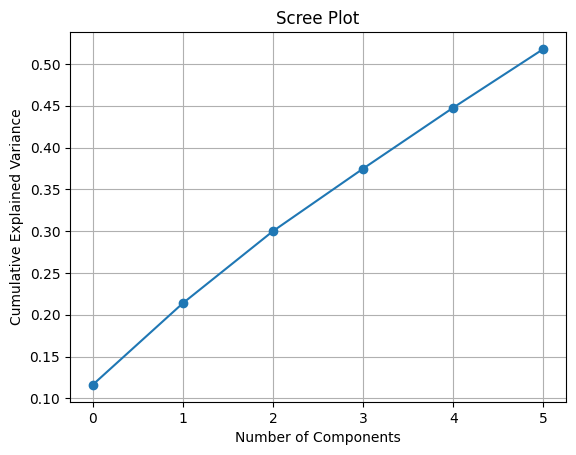

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness         -0.016998  0.089980  0.229131  0.062454  0.062058   
enjoyment             0.026514 -0.265298 -0.064040 -0.188837  0.073130   
consider              0.015925  0.077648  0.391947  0.104886  0.119564   
attention            -0.042487  0.082752 -0.110073  0.070609 -0.042629   
understand           -0.172142  0.076623 -0.119287  0.008703 -0.607786   
control-situational   0.009322  0.356868 -0.299190 -0.325451  0.370196   
control-self         -0.001763 -0.613821 -0.097383 -0.027321 -0.090985   
control-other        -0.109580 -0.137102  0.157840  0.573481  0.038862   
certainty             0.102842 -0.016969 -0.046666 -0.159042 -0.508745   
problem               0.358292  0.017354  0.064346  0.150512 -0.279813   
obstacle              0.100510  0.168302 -0.224011  0.640646  0.089192   
legitimacy-cheated    0.511438  0.019242 -0.239890  0.131250  0.117423   
legitimacy-fair      -0.087218 -0.1795

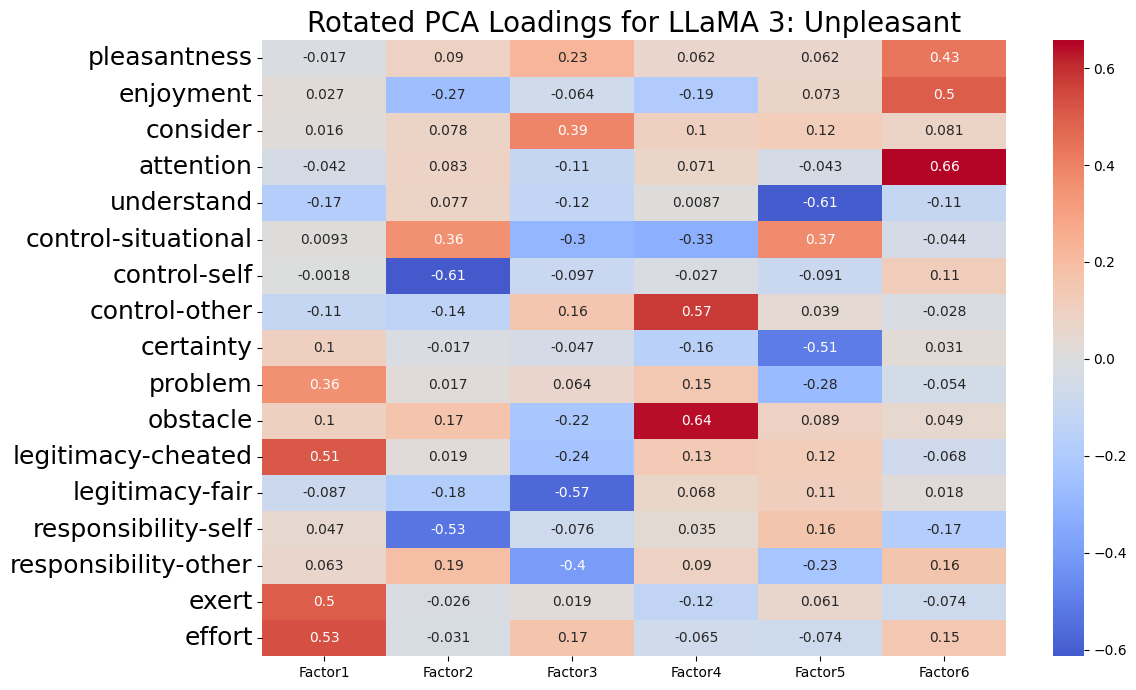

                                    Factor1  \
0              (effort, 0.5303052647538063)   
1  (legitimacy-cheated, 0.5114376982951464)   
2               (exert, 0.4995463489715571)   

                                      Factor2  \
0         (control-self, -0.6138211409768659)   
1  (responsibility-self, -0.5284376950546983)   
2  (control-situational, 0.35686808976746337)   

                                        Factor3  \
0        (legitimacy-fair, -0.5726365969807634)   
1  (responsibility-other, -0.40286754463450974)   
2               (consider, 0.39194650822732974)   

                                       Factor4  \
0                 (obstacle, 0.64064600682431)   
1           (control-other, 0.573480643427554)   
2  (control-situational, -0.32545055032902415)   

                                     Factor5  \
0          (understand, -0.6077860385862254)   
1           (certainty, -0.5087449130366088)   
2  (control-situational, 0.3701960359525986)   

               

In [86]:
llama_up_rotated_df = pca(llama_up, "LLaMA 3: Unpleasant")
# phi_rotated_df.to_csv("phi_pca_varimax.csv")
top_features = top_features_per_factor(llama_up_rotated_df)
print(top_features)

In [87]:
llama_up_explained_variance = [0.11608341, 0.09763109, 0.08624742, 0.07479534, 0.07295939, 0.07018304]
llama_up_factors = ["PF, EF", "CON, RES", "ENG, PF, RES", "CON, PR", "UND, CON, CER", "PL, ENG"]

Explained Variance Ratio = [0.39250411 0.22777719 0.05641233 0.05195203 0.04492497 0.04050868]
Total explained Variance = 0.8140793030356415


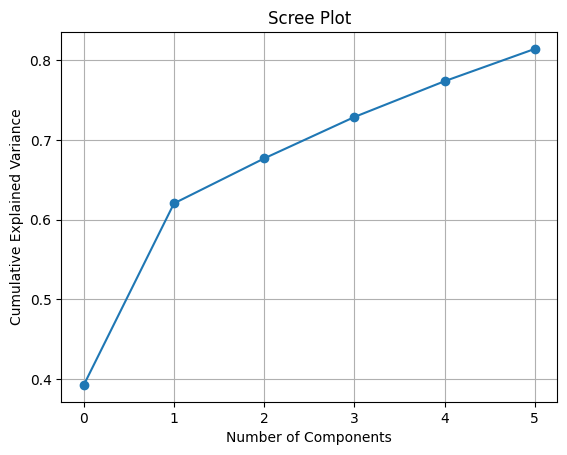

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness          0.365658  0.001170  0.022865  0.089090  0.071293   
enjoyment             0.386665  0.046690 -0.021503  0.031908  0.167966   
consider             -0.068909 -0.113756 -0.863945  0.084857  0.013507   
attention             0.375153 -0.243571  0.033839 -0.180316  0.328171   
understand            0.098664  0.089554  0.154267  0.075929  0.436923   
control-situational   0.011715 -0.019492  0.028586 -0.072787  0.021637   
control-self          0.027241  0.400584  0.070790 -0.213092  0.156269   
control-other        -0.035397 -0.696538  0.122374 -0.236917  0.172909   
certainty            -0.087993  0.046347 -0.199483  0.066992  0.716404   
problem              -0.070612  0.021061 -0.007940 -0.390098 -0.072608   
obstacle             -0.031018  0.004724 -0.085925 -0.457653 -0.027752   
legitimacy-cheated   -0.601931  0.070821  0.156674  0.089233  0.271532   
legitimacy-fair       0.415307  0.1043

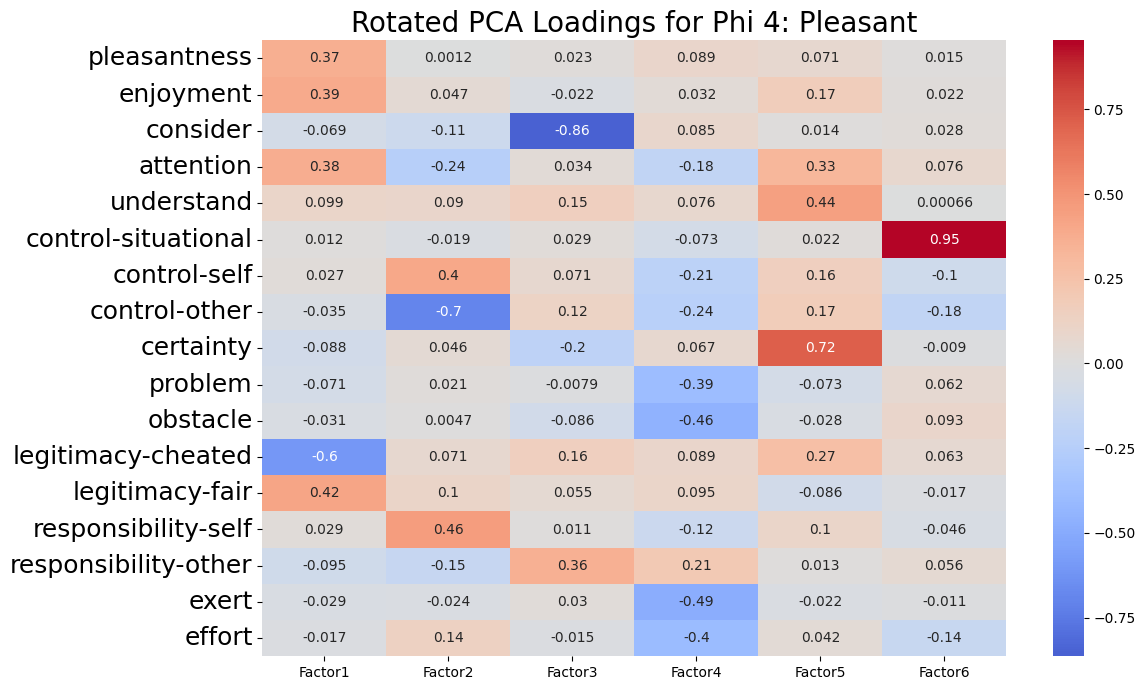

                                     Factor1  \
0  (legitimacy-cheated, -0.6019307236281901)   
1     (legitimacy-fair, 0.41530657211478633)   
2            (enjoyment, 0.3866654638485707)   

                                      Factor2  \
0        (control-other, -0.6965375715544566)   
1  (responsibility-self, 0.45789138646422417)   
2          (control-self, 0.4005839337837919)   

                                       Factor3  \
0              (consider, -0.8639452472484558)   
1  (responsibility-other, 0.36168838037282813)   
2            (certainty, -0.19948262398373717)   

                            Factor4                           Factor5  \
0      (exert, -0.4874961379486446)    (certainty, 0.716404104537736)   
1  (obstacle, -0.45765296394303584)  (understand, 0.4369231360149287)   
2    (effort, -0.39986966637893145)  (attention, 0.32817097157097713)   

                                     Factor6  
0  (control-situational, 0.9534141951434452)  
1      (control-other,

In [88]:
# calculate pleasant and unpleasant for GPT 
phi_p = phi_df[phi_df["emotion"].isin(pleasant_emotions)]
phi_up = phi_df[phi_df["emotion"].isin(unpleasant_emotions)]
phi_p_rotated_df = pca(phi_p, "Phi 4: Pleasant")
# phi_rotated_df.to_csv("phi_pca_varimax.csv")
top_features = top_features_per_factor(phi_p_rotated_df)
print(top_features)

In [90]:
phi_p_explained_variance = [0.39250411, 0.22777719, 0.05641233, 0.05195203, 0.04492497, 0.04050868]
phi_p_factors = ["PL, PF", "CON, RES", "ENG, RES", "PR, EF", "ENG, UND, CER", "CON"]

Explained Variance Ratio = [0.2521352  0.23867052 0.13667957 0.08405511 0.04820755 0.0353227 ]
Total explained Variance = 0.7950706461197411


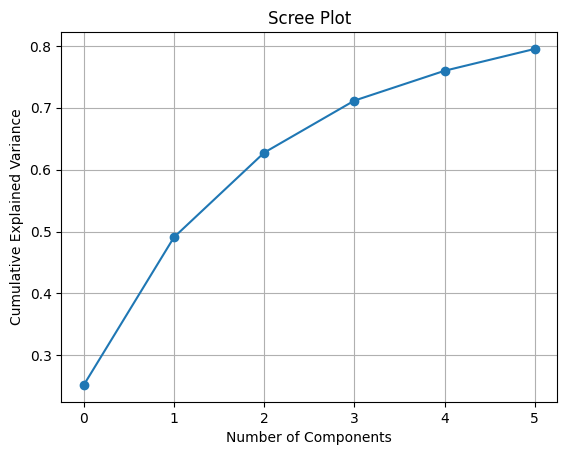

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness         -0.019565 -0.188700 -0.117833  0.552116 -0.023886   
enjoyment            -0.028216  0.038992  0.047675  0.761701 -0.020991   
consider              0.026015 -0.216023 -0.051347 -0.208043 -0.190179   
attention             0.130481  0.326566 -0.097893 -0.016990 -0.208505   
understand           -0.063129 -0.077840  0.531923 -0.057885 -0.121412   
control-situational   0.076871  0.324430 -0.079544  0.114856 -0.017021   
control-self         -0.407988  0.140005  0.152368  0.070466  0.011017   
control-other         0.402981 -0.063917 -0.048304 -0.062613  0.143044   
certainty            -0.092021 -0.146666  0.619228 -0.033425  0.067225   
problem               0.002437  0.211484  0.161678  0.002541  0.559321   
obstacle              0.018940 -0.140206 -0.190655 -0.059083  0.691179   
legitimacy-cheated    0.260400  0.213032  0.425646  0.053370  0.083446   
legitimacy-fair      -0.378597  0.0166

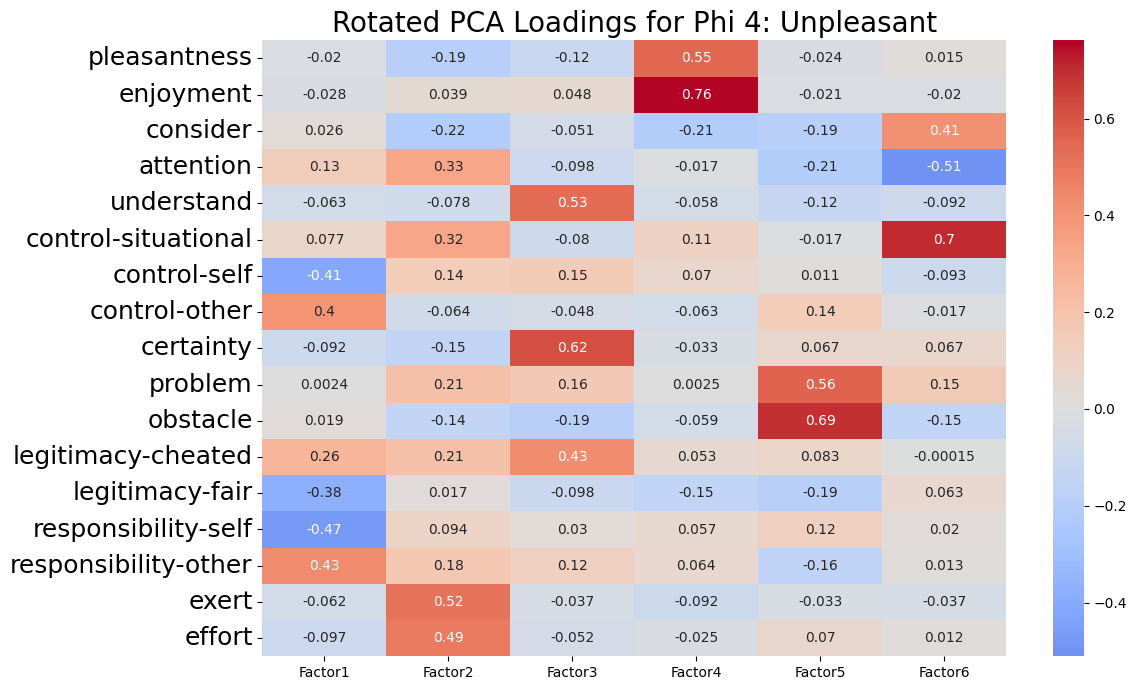

                                       Factor1  \
0  (responsibility-self, -0.47069797152462295)   
1   (responsibility-other, 0.4331309942847139)   
2         (control-self, -0.40798818525621505)   

                            Factor2                                   Factor3  \
0       (exert, 0.5165184543790778)           (certainty, 0.6192275086736977)   
1     (effort, 0.48635472858345946)           (understand, 0.531923311027058)   
2  (attention, 0.32656607689983846)  (legitimacy-cheated, 0.4256459789919768)   

                              Factor4                           Factor5  \
0     (enjoyment, 0.7617006164050885)    (obstacle, 0.6911785283460785)   
1  (pleasantness, 0.5521162521814038)     (problem, 0.5593206277942997)   
2    (consider, -0.20804255727627777)  (attention, -0.2085050681762798)   

                                    Factor6  
0  (control-situational, 0.704006908883241)  
1          (attention, -0.5110579253035543)  
2           (consider, 0.4101286308

In [89]:
phi_up_rotated_df = pca(phi_up, "Phi 4: Unpleasant")
# phi_rotated_df.to_csv("phi_pca_varimax.csv")
top_features = top_features_per_factor(phi_up_rotated_df)
print(top_features)

In [91]:
phi_up_explained_variance = [0.2521352, 0.23867052, 0.13667957, 0.08405511, 0.04820755, 0.0353227]
phi_up_factors = ["CON, PF, RES", "ENG, CON, EF", "UND, CER, PF", "PL", "PR", "ENG, CON"]

### With Emotions: Cultural Personas

Null values: 
pleasantness             47
enjoyment               111
consider                 96
attention                59
understand              109
control-situational     204
control-self            134
control-other           174
certainty               126
problem                 194
obstacle                143
legitimacy-cheated       89
legitimacy-fair         130
responsibility-self     176
responsibility-other    167
exert                   212
effort                  170
dtype: int64
Filling with Zeroes:
   pleasantness  enjoyment  consider  attention  understand  \
0           5.0       11.0       2.0        5.0        11.0   
1           5.0        0.0       3.0        5.0         0.0   
2           5.0        0.0       0.0        0.0         0.0   
3           0.0        9.0       3.0        0.0         0.0   
4           5.0       10.0       0.0        0.0         0.0   

   control-situational  control-self  control-other  certainty  problem  \
0                  0.0

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_48707/4106941317.py:53: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_filled.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)


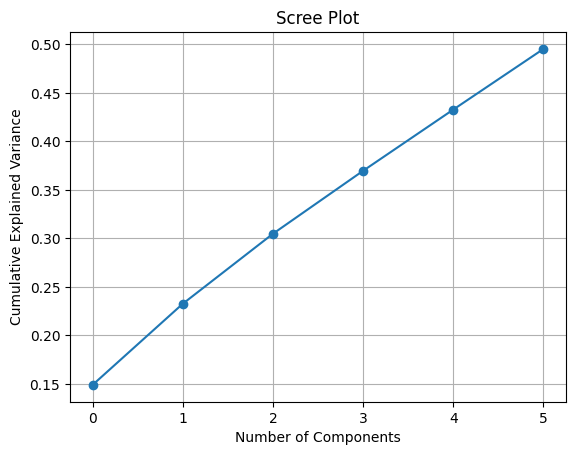

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness          0.513782  0.010992 -0.004234 -0.016660  0.000870   
enjoyment             0.390623  0.217048  0.123910  0.035509 -0.168139   
consider              0.020630 -0.070568 -0.420269  0.363790  0.143291   
attention             0.084110  0.148311  0.650189  0.098269  0.069814   
understand            0.371074 -0.144860  0.098810  0.296393 -0.072660   
control-situational   0.028012 -0.028344 -0.077758 -0.056061  0.050181   
control-self          0.100071  0.598021  0.091718 -0.066482 -0.009619   
control-other        -0.102937 -0.052696  0.037255  0.468751 -0.088615   
certainty            -0.080417  0.380502 -0.338713 -0.229375  0.021414   
problem               0.039204  0.036664  0.026932  0.026181  0.755322   
obstacle             -0.107299  0.118812  0.023504  0.101838 -0.068045   
legitimacy-cheated   -0.418658  0.033688  0.152889  0.199480 -0.234304   
legitimacy-fair       0.358084 -0.0042

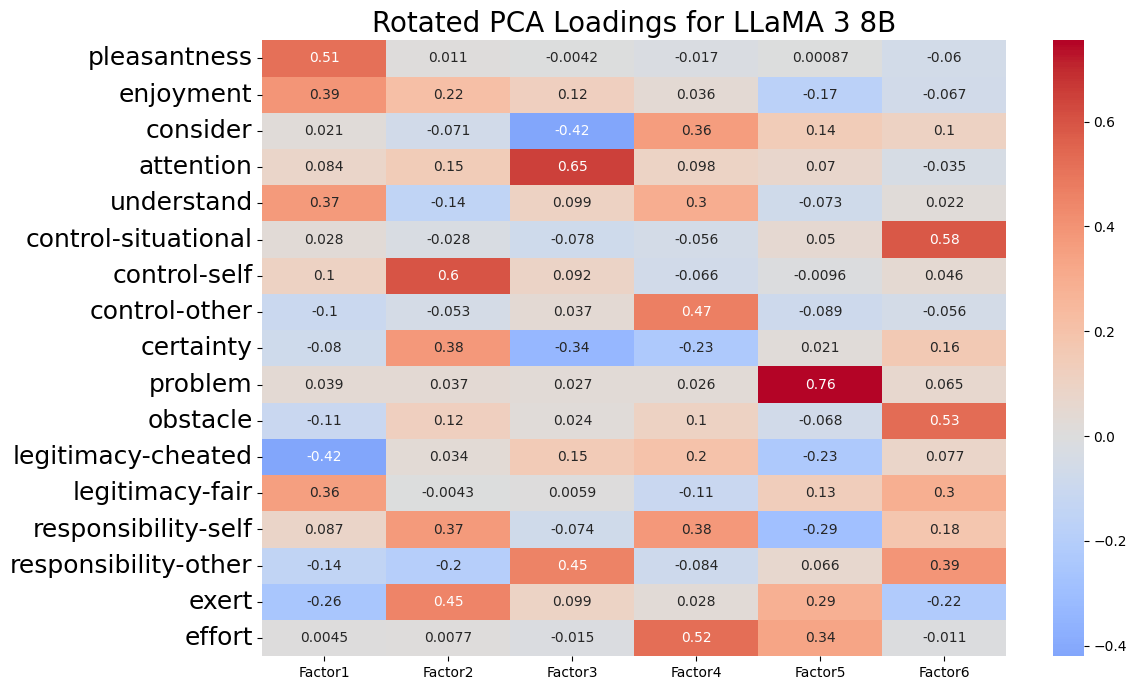

                                     Factor1  \
0         (pleasantness, 0.5137823567827584)   
1  (legitimacy-cheated, -0.4186576262863763)   
2            (enjoyment, 0.3906230320934601)   

                              Factor2  \
0  (control-self, 0.5980205230517761)   
1         (exert, 0.4498626213341399)   
2     (certainty, 0.3805024352383068)   

                                       Factor3  \
0              (attention, 0.6501889397707575)   
1  (responsibility-other, 0.45264876350135014)   
2             (consider, -0.42026895895499705)   

                                     Factor4  \
0               (effort, 0.5204107344416184)   
1        (control-other, 0.4687512293520061)   
2  (responsibility-self, 0.3829682628811249)   

                                      Factor5  \
0               (problem, 0.7553217933528539)   
1               (effort, 0.33576064802674227)   
2  (responsibility-self, -0.2904959339044093)   

                                      Factor6  
0  

In [18]:
# LLama 3 8B with USA persona
llama_usa_dict = get_appraisal_data("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/llama_3_8b_with_emotion_usa.jsonl")
llama_usa_df = process_df(llama_usa_dict)
llama_usa_rotated_df = pca(llama_usa_df, "LLaMA 3 8B")
# llama_rotated_df.to_csv("llama_pca_varimax.csv")
top_features_llama_usa = top_features_per_factor(llama_usa_rotated_df)
print(top_features_llama_usa)

Null values: 
pleasantness             36
enjoyment                69
consider                110
attention                55
understand               91
control-situational     161
control-self             96
control-other           156
certainty               164
problem                 155
obstacle                 89
legitimacy-cheated      111
legitimacy-fair         122
responsibility-self     171
responsibility-other    153
exert                   190
effort                  158
dtype: int64
Filling with Zeroes:
   pleasantness  enjoyment  consider  attention  understand  \
0           5.0        9.0       3.0        5.0         8.0   
1           5.0       11.0       3.0        4.0         0.0   
2           5.0        9.0       2.0        0.0         8.0   
3           0.0       11.0       0.0        0.0         9.0   
4           5.0       11.0       1.0        5.0        11.0   

   control-situational  control-self  control-other  certainty  problem  \
0                  2.0

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_48707/4106941317.py:53: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_filled.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)


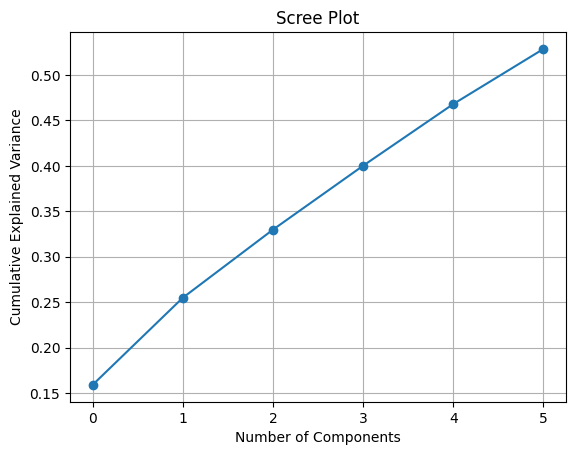

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness          0.441630 -0.023393 -0.011883 -0.001184  0.058500   
enjoyment             0.462681 -0.066526  0.042924  0.249077  0.043105   
consider             -0.002088 -0.021731  0.016578  0.126350 -0.024517   
attention             0.046385  0.086840  0.365361  0.312932  0.441629   
understand            0.416423 -0.029422  0.032272  0.005846 -0.049541   
control-situational   0.078080  0.253108 -0.145827  0.358592  0.066249   
control-self          0.359285  0.237271  0.168386 -0.106425 -0.147498   
control-other        -0.076664  0.446057 -0.065930 -0.024554  0.239388   
certainty            -0.128753  0.025148  0.713386 -0.137408  0.037526   
problem              -0.085380 -0.145973 -0.066970  0.668288 -0.012664   
obstacle             -0.164137 -0.099286  0.004083  0.083062 -0.447813   
legitimacy-cheated   -0.427274  0.056738  0.214808  0.183146 -0.112410   
legitimacy-fair       0.146786 -0.1227

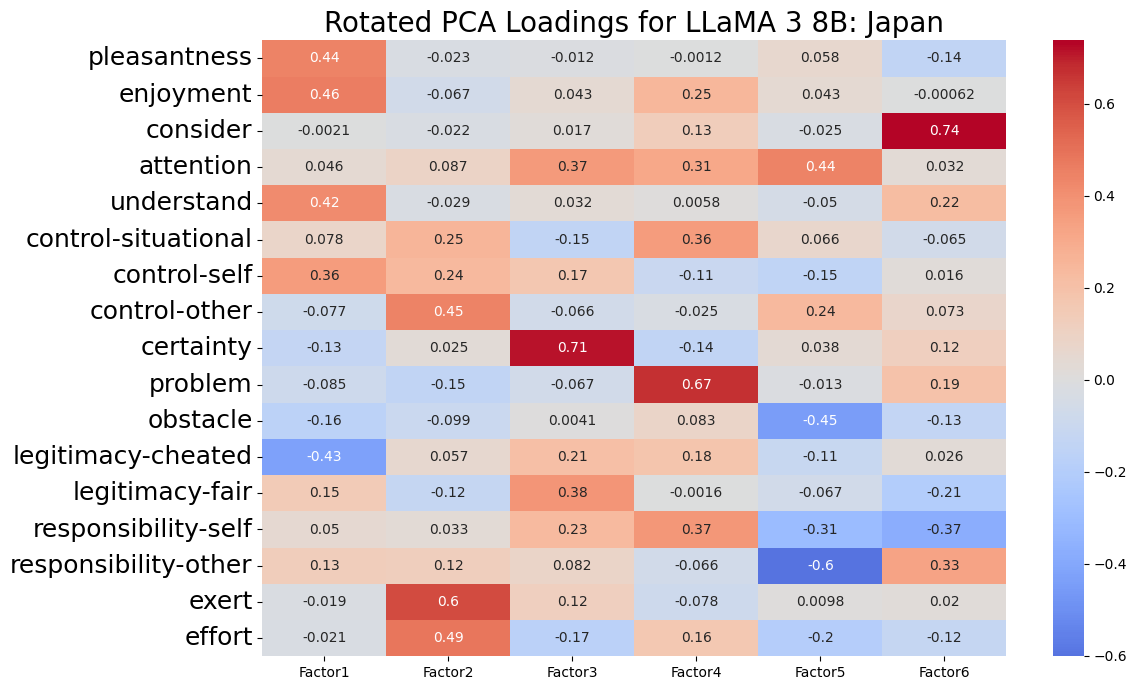

                                     Factor1  \
0            (enjoyment, 0.4626812876229553)   
1        (pleasantness, 0.44163012294317067)   
2  (legitimacy-cheated, -0.4272739123418724)   

                                Factor2  \
0           (exert, 0.6026580737920949)   
1         (effort, 0.48695246248471435)   
2  (control-other, 0.44605713056772733)   

                                 Factor3  \
0        (certainty, 0.7133864898890897)   
1  (legitimacy-fair, 0.3824764716181867)   
2       (attention, 0.36536100757684575)   

                                      Factor4  \
0               (problem, 0.6682876166900686)   
1  (responsibility-self, 0.37472866179842235)   
2  (control-situational, 0.35859235978563986)   

                                       Factor5  \
0  (responsibility-other, -0.6012264699957771)   
1              (obstacle, -0.4478133284869556)   
2             (attention, 0.44162910305124276)   

                                       Factor6  
0         

In [20]:
# LLama 3 8B with Japan persona
llama_jp_dict = get_appraisal_data("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/llama_3_8b_with_emotion_japan.jsonl")
llama_jp_df = process_df(llama_jp_dict)
llama_jp_rotated_df = pca(llama_jp_df, "LLaMA 3 8B: Japan")
# llama_rotated_df.to_csv("llama_pca_varimax.csv")
top_features_llama_jp = top_features_per_factor(llama_jp_rotated_df)
print(top_features_llama_jp)

Null values: 
pleasantness             39
enjoyment                76
consider                 92
attention                54
understand              109
control-situational     155
control-self            105
control-other           156
certainty               136
problem                 175
obstacle                114
legitimacy-cheated       94
legitimacy-fair         109
responsibility-self     182
responsibility-other    153
exert                   205
effort                  156
dtype: int64
Filling with Zeroes:
   pleasantness  enjoyment  consider  attention  understand  \
0           5.0        9.0       1.0        4.0         8.0   
1           5.0        9.0       5.0        5.0         0.0   
2           5.0        8.0       5.0        0.0         9.0   
3           0.0       11.0       5.0        4.0         9.0   
4           5.0       10.0       2.0        5.0         9.0   

   control-situational  control-self  control-other  certainty  problem  \
0                  1.0

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_48707/4106941317.py:53: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_filled.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)


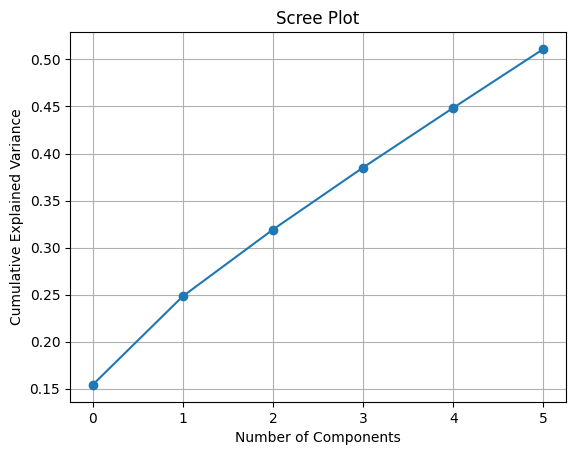

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness          0.508242  0.006609 -0.021042  0.049387  0.013534   
enjoyment             0.496107  0.099692 -0.025193 -0.049644  0.106933   
consider             -0.113923  0.169519  0.032957 -0.583838 -0.012077   
attention            -0.012008 -0.214765 -0.309257  0.133205  0.447824   
understand            0.171211 -0.125492  0.042709  0.140852  0.391236   
control-situational   0.102260  0.559149 -0.013623  0.020837  0.109442   
control-self          0.308414  0.177566  0.270556 -0.026009  0.290842   
control-other        -0.049578  0.122398 -0.174856 -0.127507  0.204157   
certainty             0.048588 -0.221967  0.618157 -0.072573 -0.071172   
problem              -0.029975  0.359013 -0.001376  0.398979 -0.197938   
obstacle              0.073964  0.109418  0.200485  0.358005 -0.235516   
legitimacy-cheated   -0.473041  0.096978  0.043367  0.042858  0.129669   
legitimacy-fair       0.112066  0.1518

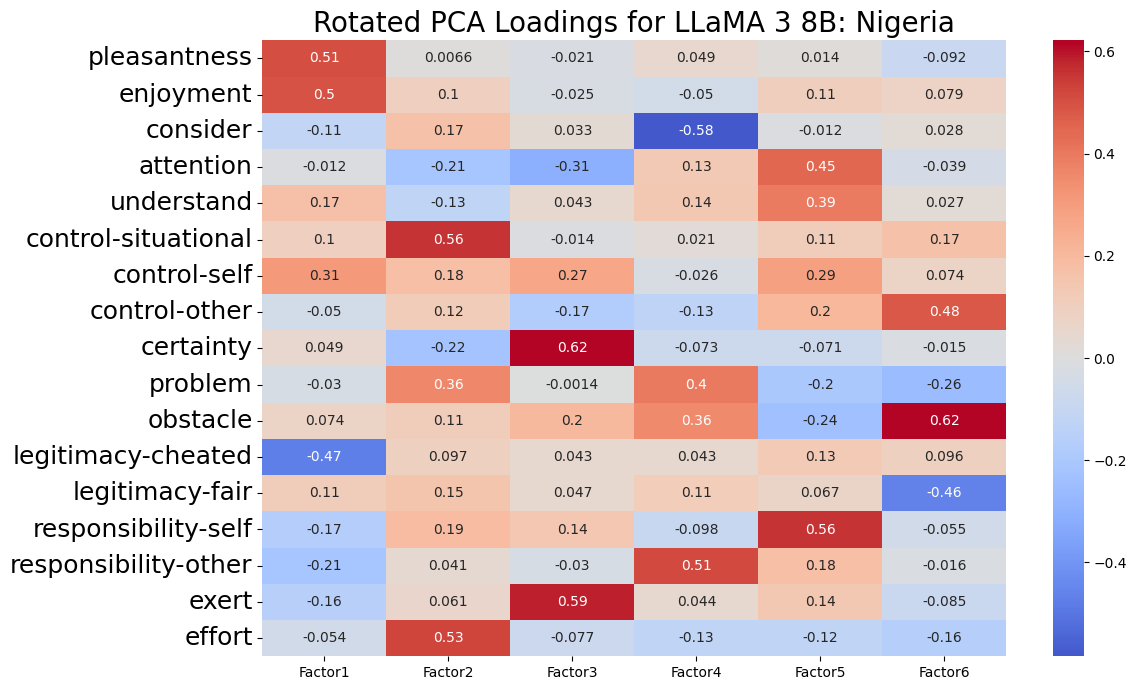

                                      Factor1  \
0          (pleasantness, 0.5082418338717264)   
1             (enjoyment, 0.4961073289817069)   
2  (legitimacy-cheated, -0.47304123624573313)   

                                     Factor2  \
0  (control-situational, 0.5591487453712132)   
1               (effort, 0.5253396886349609)   
2              (problem, 0.3590126297706033)   

                             Factor3  \
0     (certainty, 0.618157450638442)   
1        (exert, 0.5850211163972161)   
2  (attention, -0.30925684441925366)   

                                      Factor4  \
0             (consider, -0.5838381133538311)   
1  (responsibility-other, 0.5140408148080466)   
2              (problem, 0.39897909084823446)   

                                     Factor5  \
0  (responsibility-self, 0.5559819329370126)   
1            (attention, 0.4478242361726935)   
2           (understand, 0.3912362238289684)   

                                  Factor6  
0          (obs

In [21]:
# LLama 3 8B with Nigeria persona
llama_ng_dict = get_appraisal_data("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/llama_3_8b_with_emotion_nigeria.jsonl")
llama_ng_df = process_df(llama_ng_dict)
llama_ng_rotated_df = pca(llama_ng_df, "LLaMA 3 8B: Nigeria")
# llama_rotated_df.to_csv("llama_pca_varimax.csv")
top_features_llama_ng = top_features_per_factor(llama_ng_rotated_df)
print(top_features_llama_ng)

Null values: 
pleasantness             45
enjoyment                87
consider                 94
attention                61
understand              106
control-situational     157
control-self             98
control-other           170
certainty               158
problem                 173
obstacle                120
legitimacy-cheated      121
legitimacy-fair         122
responsibility-self     188
responsibility-other    162
exert                   216
effort                  166
dtype: int64
Filling with Zeroes:
   pleasantness  enjoyment  consider  attention  understand  \
0           5.0        9.0       3.0        5.0         9.0   
1           5.0       11.0       5.0        0.0         0.0   
2           5.0        9.0       3.0        4.0         8.0   
3           0.0       11.0       1.0        3.0         9.0   
4           0.0        9.0       1.0        5.0        11.0   

   control-situational  control-self  control-other  certainty  problem  \
0                  1.0

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_48707/4106941317.py:53: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_filled.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)


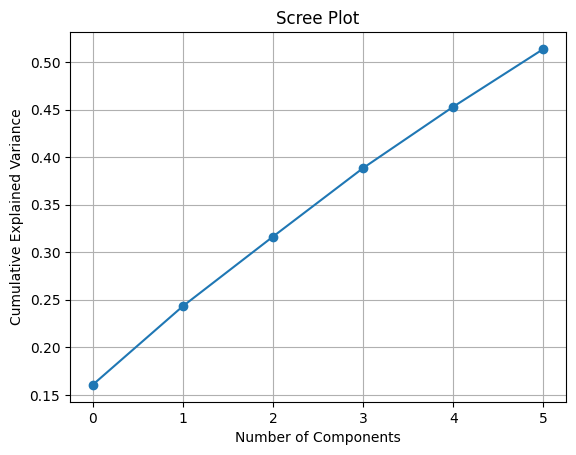

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness          0.517631 -0.065551 -0.052416  0.108084 -0.006241   
enjoyment             0.523256 -0.041132  0.090631  0.041711  0.073469   
consider             -0.050144 -0.036365 -0.169913  0.249567 -0.164603   
attention             0.251961  0.390640 -0.039926  0.023989 -0.063322   
understand            0.263620  0.229130  0.050398 -0.349775 -0.019029   
control-situational   0.182834 -0.077691  0.107807  0.543680 -0.065564   
control-self          0.168597 -0.015544  0.581946 -0.127271  0.022063   
control-other         0.073364  0.134111 -0.134321  0.592735  0.040245   
certainty             0.114079 -0.076705  0.181992  0.048539  0.754957   
problem              -0.052801  0.587684  0.062373  0.077292 -0.124235   
obstacle             -0.043699  0.278657  0.253707  0.155383  0.128460   
legitimacy-cheated   -0.289235  0.101207  0.129527  0.286916  0.219671   
legitimacy-fair       0.289972  0.2080

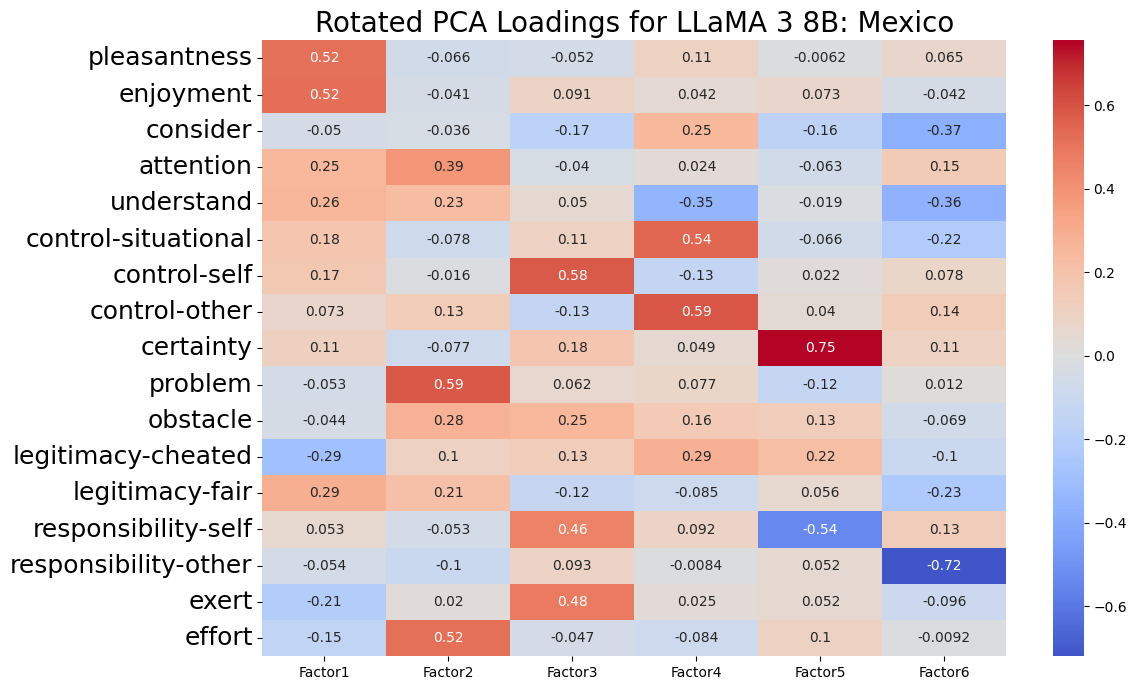

                                  Factor1                          Factor2  \
0          (enjoyment, 0.523256205583045)    (problem, 0.5876843161981535)   
1      (pleasantness, 0.5176314879245801)     (effort, 0.5172648818863295)   
2  (legitimacy-fair, 0.28997247976203055)  (attention, 0.3906399544290085)   

                                      Factor3  \
0          (control-self, 0.5819460788020749)   
1                 (exert, 0.4836798929525548)   
2  (responsibility-self, 0.45856900350322294)   

                                     Factor4  \
0        (control-other, 0.5927346941611736)   
1  (control-situational, 0.5436797645150301)   
2          (understand, -0.3497750485645071)   

                                      Factor5  \
0              (certainty, 0.754956660286113)   
1  (responsibility-self, -0.5363468791716418)   
2   (legitimacy-cheated, 0.21967092784630549)   

                                       Factor6  
0  (responsibility-other, -0.7196207225657293)  
1 

In [22]:
# LLama 3 8B with Mexico persona
llama_mx_dict = get_appraisal_data("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/llama_3_8b_with_emotion_mexico.jsonl")
llama_mx_df = process_df(llama_mx_dict)
llama_mx_rotated_df = pca(llama_mx_df, "LLaMA 3 8B: Mexico")
# llama_rotated_df.to_csv("llama_pca_varimax.csv")
top_features_llama_mx = top_features_per_factor(llama_mx_rotated_df)
print(top_features_llama_mx)

Null values: 
pleasantness             46
enjoyment                94
consider                105
attention                66
understand               93
control-situational     146
control-self            107
control-other           164
certainty               167
problem                 183
obstacle                127
legitimacy-cheated      127
legitimacy-fair         107
responsibility-self     170
responsibility-other    170
exert                   190
effort                  159
dtype: int64
Filling with Zeroes:
   pleasantness  enjoyment  consider  attention  understand  \
0           5.0        9.0       2.0        5.0         9.0   
1           5.0       10.0       5.0        4.0         0.0   
2           5.0        0.0       5.0        0.0         9.0   
3           0.0       11.0       3.0        4.0         9.0   
4           5.0       11.0       1.0        5.0        11.0   

   control-situational  control-self  control-other  certainty  problem  \
0                  1.0

/var/folders/kr/pv72kj_95w1bmp_0t9gtmdrw0000gn/T/ipykernel_48707/4106941317.py:53: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_filled.applymap(lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x)


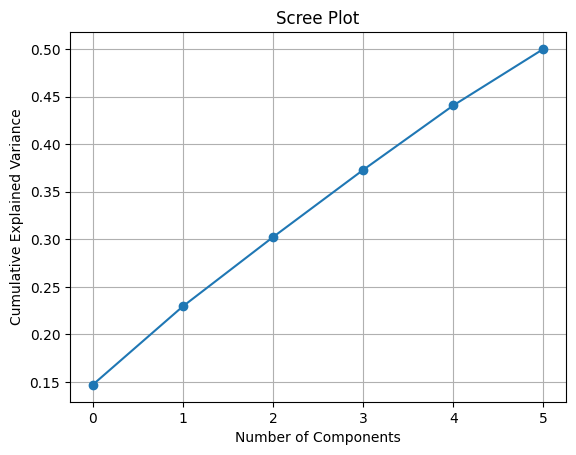

                       Factor1   Factor2   Factor3   Factor4   Factor5  \
pleasantness          0.457887 -0.043251  0.101940  0.028538  0.077532   
enjoyment             0.413426  0.115768 -0.121373 -0.008699  0.067636   
consider             -0.076112 -0.034935 -0.080269  0.025340 -0.063561   
attention             0.112549  0.470865  0.101446  0.055129 -0.025522   
understand            0.313134  0.071396 -0.046613  0.000098 -0.089688   
control-situational   0.015635  0.204910 -0.138621 -0.571867  0.215663   
control-self          0.276163  0.075604 -0.046815  0.149122 -0.283404   
control-other         0.021233 -0.142341 -0.031732 -0.615307 -0.228026   
certainty            -0.086188  0.590545  0.064863 -0.057743  0.141046   
problem              -0.075638  0.117047  0.675222 -0.005274 -0.199387   
obstacle             -0.228152  0.081675  0.077413 -0.295207 -0.031417   
legitimacy-cheated   -0.411715  0.260505 -0.064545 -0.012589 -0.025615   
legitimacy-fair       0.240996  0.4489

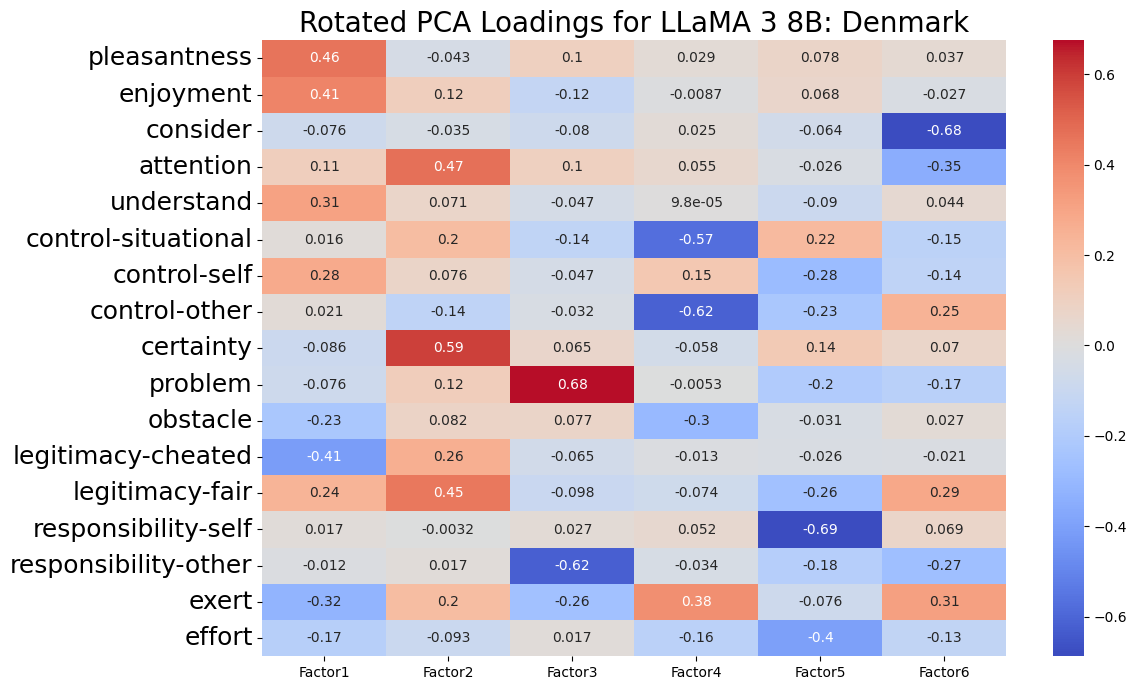

                                     Factor1  \
0         (pleasantness, 0.4578866175210579)   
1            (enjoyment, 0.4134261299186929)   
2  (legitimacy-cheated, -0.4117154140013538)   

                                  Factor2  \
0         (certainty, 0.5905454006298463)   
1        (attention, 0.47086468403013976)   
2  (legitimacy-fair, 0.44890769606380354)   

                                       Factor3  \
0                (problem, 0.6752219804365717)   
1  (responsibility-other, -0.6219140620779281)   
2                 (exert, -0.2568377646478412)   

                                      Factor4  \
0        (control-other, -0.6153071907427852)   
1  (control-situational, -0.5718670232960047)   
2                 (exert, 0.3776461088648949)   

                                      Factor5  \
0  (responsibility-self, -0.6875156601388558)   
1              (effort, -0.40115973057020443)   
2         (control-self, -0.2834040982551109)   

                             Fa

In [23]:
# LLama 3 8B with Denmark persona
llama_dn_dict = get_appraisal_data("/Users/sreebhattacharyya/Desktop/PSU (PhD)/Research Projects/cogapp/results/llama_3_8b_with_emotion_denmark.jsonl")
llama_dn_df = process_df(llama_dn_dict)
llama_dn_rotated_df = pca(llama_dn_df, "LLaMA 3 8B: Denmark")
# llama_rotated_df.to_csv("llama_pca_varimax.csv")
top_features_llama_dn = top_features_per_factor(llama_dn_rotated_df)
print(top_features_llama_dn)

In [ ]:
# The top 6 factors for Llama: 
# 1. lack of fairness / high pleasantness, high enjoyment (pleasantness - high)
# 2. High other responsibility (AND high certainty) (responsibility - high other)
# 3. High attention, high situational or other control (control - high other)
# 4. High perceived fairness, high self control/responsibility (perceived fairness - high)
# 5. Lack of effort or exertion, lack of considering/engagement (effort - low)
# 6. High understanding (also high effort and problem) (understanding - high)

# Top Factors for LLama with USA: 
# 1. high pleasantness, high enjoyment (pleasantness - high)
# 2. high self-control, high certainty (but also high effort) (control - high self, effort - high)
# 3. High attention, engagement, high other-responsibility (engagement - high)
# 4. High effort (effort - high)
# 5. High problem (problem - high)
# 6. High situational control, obstacle (control - high situational)

# Top 6 Factors with Japan: 
# 1. high enjoyment, high pleasantness 
# 2. high effort, high exertion
# 3. High certainty 
# 4. high problem
# 5. lack of other responsibility, lack of obstacle 
# 6. lack of consideration, lack of self-responsibility

# Top 6 Factors with Nigeria: 
# 1. high pleasantness, high enjoyment
# 2. high situational control, high effort, high problem 
# 3. high certainty 
# 4. high consideration (engagement), high other-responsibility 
# 5. high self responsibility 
# 6. high obstacle, other-control 

# Top 6 Factors with Mexico
# 1. high enjoyment, high pleasantness
# 2. high problem, high effort, high exertion
# 3. high self-control
# 4. high other/situational control 
# 5. high certainty, low self-responsibility
# 6. low other-responsibility 

# Top 6 Factors with Denmark:
# 1. high pleasantness, high enjoyment 
# 2. high certainty, high attention 
# 3.high problem, low other-responsibility
# 4. lack of other control/situational control 
# 5. lack of self-responsibility, effort
# 6. high consideration, lack of attention